# Baseline Technical Analysis — SMA Crossover with ATR Risk

This notebook establishes a **baseline** quantitative workflow for evaluating a technical
strategy across two distinct market groups (Forex and B3/Bovespa) and multiple
timeframes — so we can identify which horizon produces the best risk-adjusted edge.

1. **Load** every OHLC CSV from `../data/`, now organised into `forex/` and `b3/`
   subdirectories. Filenames follow `<ASSET>_<TF>_<START>_<END>.csv`.
2. **Prepare** multi-timeframe versions of each asset — different target timeframes
   are explored per group.
3. **Describe** a simple, fully-specified strategy (SMA crossover with ATR-based risk).
4. **Backtest** and compute standard performance metrics — **separately** for each
   group (Forex / B3) and each timeframe.
5. **Visualize** results with a dashboard (equity curve, drawdown, PnL distribution,
   rolling win rate).
6. **Optimize** parameters with **Walk-Forward Optimization** (WFO) — per group,
   per timeframe — and inspect stitched out-of-sample performance.
7. **Stress-test** robustness (Monte-Carlo shuffling and parameter-sensitivity sweeps)
   for each group's best-performing timeframe.

Heavy lifting lives in `../source/` so other notebooks can reuse the same components.

In [1]:
# Make the `source/` package importable from this notebook's location.
import gc
import sys
from pathlib import Path
from collections import Counter

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    discover_datasets,
    build_lazy_grid,
    LazyDataset,
    SMACrossoverStrategy,
    StrategyParams,
    Backtester,
    compute_metrics,
    metrics_table,
    plot_backtest_dashboard,
    plot_wfo_dashboard,
    plot_robustness_dashboard,
    walk_forward,
    WFOResult,
    monte_carlo_trades,
    monte_carlo_summary,
    block_bootstrap_trades,
    subperiod_analysis,
    parameter_sensitivity,
    correlation_weights,
    weighted_portfolio,
    run_backtest_grid,
    run_wfo_grid,
    reshape_grid_results,
    cpu_count,
)

pd.set_option("display.float_format", "{:,.4f}".format)
plt.rcParams["figure.dpi"] = 110
N_JOBS = "auto"           # parallelism budget; set to 1 to force serial
print(f"Parallelism budget: n_jobs={N_JOBS!r} (cpu_count={cpu_count()})")


Parallelism budget: n_jobs='auto' (cpu_count=15)


## 1. Load the data

`load_all` scans both root-level CSVs **and** named subdirectories under `../data/`.
The subdirectory name (`forex`, `b3`, …) becomes each dataset's `group` tag.
Filename format: `<ASSET>_<TIMEFRAME>_<STARTYYYYMMDDHHMM>_<ENDYYYYMMDDHHMM>.csv`.

In [2]:
# Metadata-only discovery — no CSVs are read at this point, so RAM stays flat
# even as the data dir grows.  Use ds.load() / ds.unload() (or ds.using()
# context manager) to materialise a single DataFrame at a time.
metas = discover_datasets(REPO_ROOT / "data")
print(f"Discovered {len(metas)} dataset(s):")
for (asset, tf), meta in metas.items():
    group_tag = f"[{meta.group}]" if meta.group else "[root]"
    print(f"  {group_tag:8s} {asset:8s} {tf:4s}  {meta.start.date()} -> {meta.end.date()}")

forex_assets = sorted({a for (a, _), m in metas.items() if m.group == "forex"})
b3_assets    = sorted({a for (a, _), m in metas.items() if m.group == "b3"})
print(f"\nForex assets : {forex_assets}")
print(f"B3 assets    : {b3_assets}")


Discovered 5 dataset(s):
  [b3]     WDO      M1    2021-04-30 -> 2026-04-29
  [b3]     WIN      M1    2021-04-30 -> 2026-04-29
  [forex]  EURCAD   M1    2016-04-11 -> 2026-04-21
  [forex]  EURUSD   M1    2016-04-11 -> 2026-04-21
  [forex]  GBPCHF   M1    2016-04-11 -> 2026-04-21

Forex assets : ['EURCAD', 'EURUSD', 'GBPCHF']
B3 assets    : ['WDO', 'WIN']


## 2. Multi-timeframe preparation

Different markets suit different analysis horizons:

| Group | Timeframes explored | Rationale |
|-------|---------------------|-----------|
| Forex | 1 h · 4 h · 1 D | 24/5 market; enough bars even at daily resolution |
| B3    | 1 min · 5 min · 15 min · 30 min | ~8 h session/day; daily bars would be too sparse |

Each M1 dataset is resampled to every target timeframe. Results in Sections 3–5 show
which horizon produces the best risk-adjusted edge per group.

In [3]:
GROUP_TIMEFRAMES = {
    "forex": ["1h", "4h", "1D"],
    "b3":    ["1min", "5min", "15min", "30min"],
}

# `build_lazy_grid` returns {group: {tf: {asset: LazyDataset}}}.  Nothing is
# loaded yet; each LazyDataset reads + resamples its CSV the first time
# .load() is called and frees the cache on .unload().  The runners in
# `source.runner` materialise the frame *inside the worker process*, so the
# parent kernel never holds more than a single frame at a time.
group_tfs = build_lazy_grid(REPO_ROOT / "data", group_timeframes=GROUP_TIMEFRAMES)

for group, tfs in group_tfs.items():
    print(f"\n{group.upper()}:")
    for tf, assets in tfs.items():
        print(f"  {tf:6s}  assets={list(assets)}")



B3:
  1min    assets=['WDO', 'WIN']
  5min    assets=['WDO', 'WIN']
  15min   assets=['WDO', 'WIN']
  30min   assets=['WDO', 'WIN']

FOREX:
  1h      assets=['EURCAD', 'EURUSD', 'GBPCHF']
  4h      assets=['EURCAD', 'EURUSD', 'GBPCHF']
  1D      assets=['EURCAD', 'EURUSD', 'GBPCHF']


## 3. Strategy definition — SMA crossover with ATR-based risk

**Entry**
- Long when the fast SMA crosses above the slow SMA (bar close).
- Short when the fast SMA crosses below the slow SMA.

**Exit**
- Hard stop loss: `entry − direction × sl_atr_mult × ATR`.
- Take profit:    `entry + direction × tp_atr_mult × ATR`.
- Reverse on the opposite crossover.

**Risk plan**
- One unit per trade; PnL in price points.
- Intrabar priority: stop loss before take profit (pessimistic assumption).
- No pyramiding; always flat between signals.

Baseline parameters are the same across all timeframes and groups — WFO in Section 4
will find the per-(group, timeframe) optimal values.

In [4]:
baseline_params = StrategyParams(
    fast=20,
    slow=50,
    atr_period=14,
    sl_atr_mult=2.0,
    tp_atr_mult=3.0,
)

SUMMARY_METRICS = [
    "num_trades", "total_pnl", "win_rate", "profit_factor",
    "expectancy", "max_drawdown", "sharpe_daily", "sharpe_per_trade", "p_value",
]


class _PortfolioResult:
    """Lightweight result container for a combined multi-asset portfolio."""
    def __init__(self, trades, equity):
        self.trades = trades
        self.equity = equity


def build_portfolio(per_asset_results):
    """Merge per-asset BacktestResult objects into a single portfolio."""
    frames = []
    for asset, result in per_asset_results.items():
        if not result.trades.empty:
            t = result.trades.copy()
            t.insert(0, "asset", asset)
            frames.append(t)
    if not frames:
        return _PortfolioResult(pd.DataFrame(), pd.Series(dtype=float))
    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    equity = pd.Series(
        combined["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined["exit_time"].values),
        name="equity_points",
    )
    return _PortfolioResult(combined, equity)


def metrics_comparison(portfolio_dict, keys=None):
    """Compare portfolio metrics across TFs. Columns = TFs, rows = metrics."""
    keys = keys or SUMMARY_METRICS
    rows = {}
    for tf, portfolio in portfolio_dict.items():
        m = compute_metrics(portfolio)
        rows[tf] = {k: m[k] for k in keys if k in m}
    return pd.DataFrame(rows)


In [5]:
# Run every (group, tf, asset) baseline backtest in parallel.  Each worker
# loads + resamples its own CSV slice, runs the backtest, and returns the
# result; the parent only ever holds the (small) BacktestResult objects.
flat_results = run_backtest_grid(
    group_tfs,
    baseline_params,
    strategy_cls=SMACrossoverStrategy,
    n_jobs=N_JOBS,
)
baseline_per_asset = reshape_grid_results(flat_results)
baseline_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in baseline_per_asset.items()
}

for group in baseline_portfolio:
    for tf, portfolio in baseline_portfolio[group].items():
        n = len(portfolio.trades) if not portfolio.trades.empty else 0
        print(f"{group:5s}  {tf:6s}  {n:>6,} trades")


  backtest [17/17]


b3     1min    31,989 trades
b3     5min     6,247 trades
b3     15min    2,100 trades
b3     30min      992 trades
forex  1h       4,193 trades
forex  4h       1,106 trades
forex  1D         192 trades


### 3.1 Forex — baseline across timeframes

Portfolio metrics (all Forex assets combined) for each target timeframe, followed by a
per-asset breakdown and equity-curve dashboards.

In [6]:
print("Portfolio metrics — Forex (all assets combined, per timeframe):")
display(metrics_comparison(baseline_portfolio["forex"]))

print("\nPer-asset breakdown by timeframe:")
for tf, asset_results in baseline_per_asset["forex"].items():
    print(f"\n  {tf}:")
    detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
    display(
        pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ]
    )

Portfolio metrics — Forex (all assets combined, per timeframe):


,1h,4h,1D
num_trades,"4,193.0000","1,106.0000",192.0000
total_pnl,-0.5551,-0.1526,-0.8086
win_rate,0.3866,0.3843,0.3021
profit_factor,0.9305,0.9634,0.6320
expectancy,-0.0001,-0.0001,-0.0042
max_drawdown,-0.5771,-0.4764,-0.7955
sharpe_daily,-0.4925,-0.1363,-0.7363
sharpe_per_trade,-2.0333,-0.5554,-2.9468
p_value,0.0420,0.5786,0.0032



Per-asset breakdown by timeframe:

  1h:


,EURCAD,EURUSD,GBPCHF
num_trades,"1,414.0000","1,374.0000","1,405.0000"
total_pnl,-0.3404,0.0953,-0.3100
sharpe_daily,-0.4948,0.1882,-0.4925
profit_factor,0.8885,1.0453,0.8904
max_drawdown,-0.3498,-0.1402,-0.3560



  4h:


,EURCAD,EURUSD,GBPCHF
num_trades,384.0000,371.0000,351.0000
total_pnl,-0.3330,0.0605,0.1200
sharpe_daily,-0.4962,0.1160,0.1940
profit_factor,0.8053,1.0512,1.0937
max_drawdown,-0.3700,-0.1715,-0.1422



  1D:


,EURCAD,EURUSD,GBPCHF
num_trades,68.0000,58.0000,66.0000
total_pnl,-0.3434,-0.0653,-0.3999
sharpe_daily,-0.5280,-0.1258,-0.5994
profit_factor,0.5818,0.8723,0.5379
max_drawdown,-0.3641,-0.1491,-0.4347


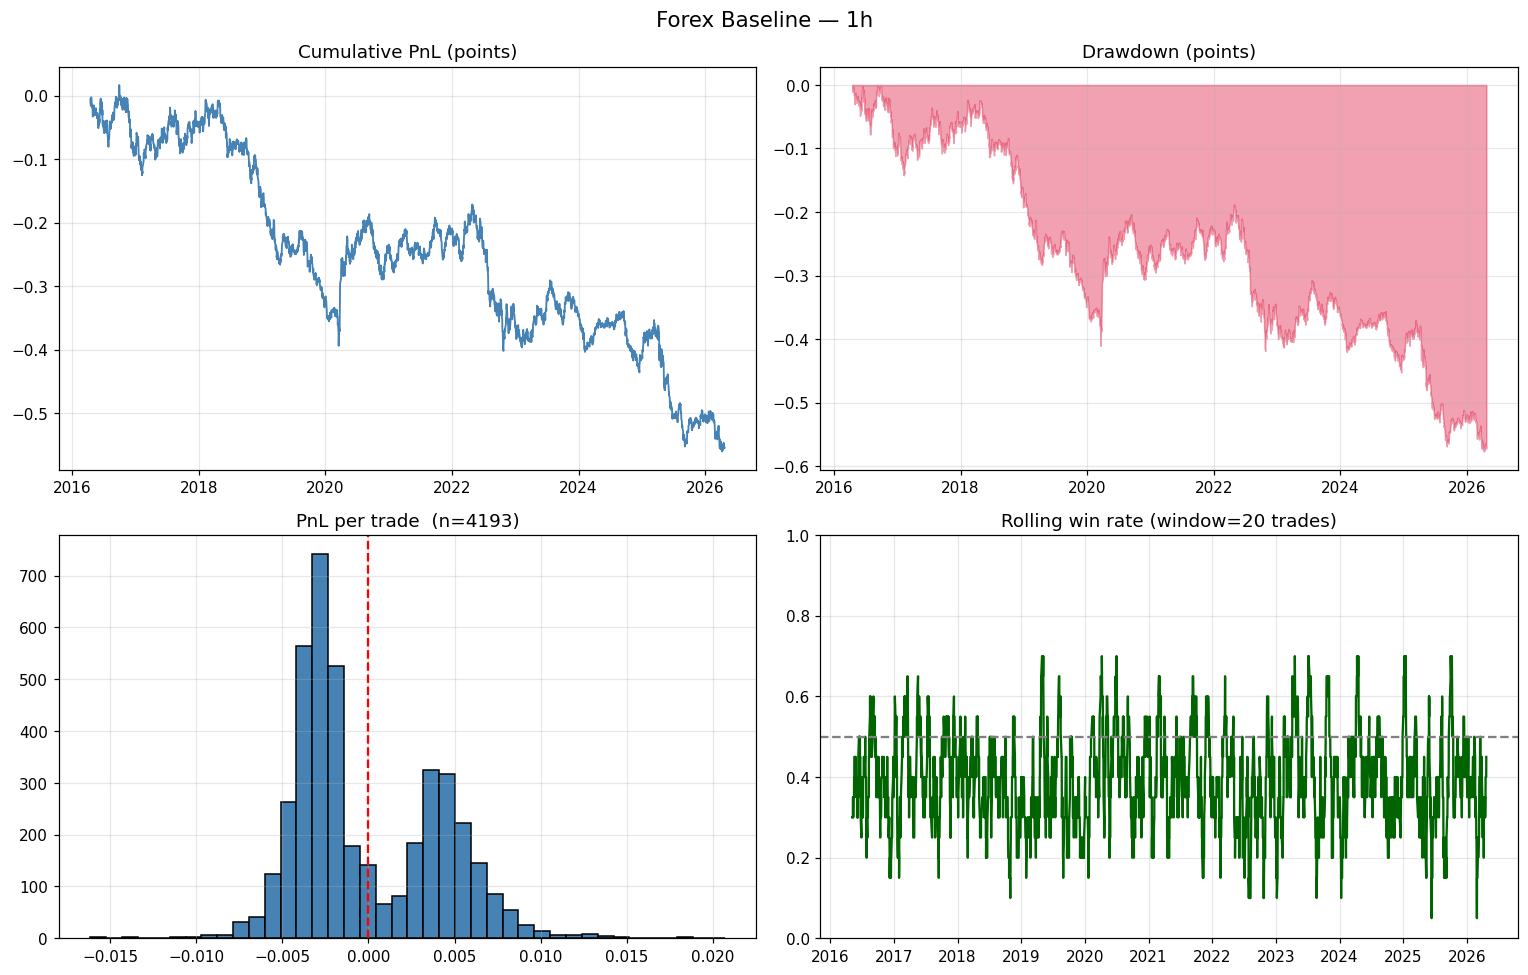

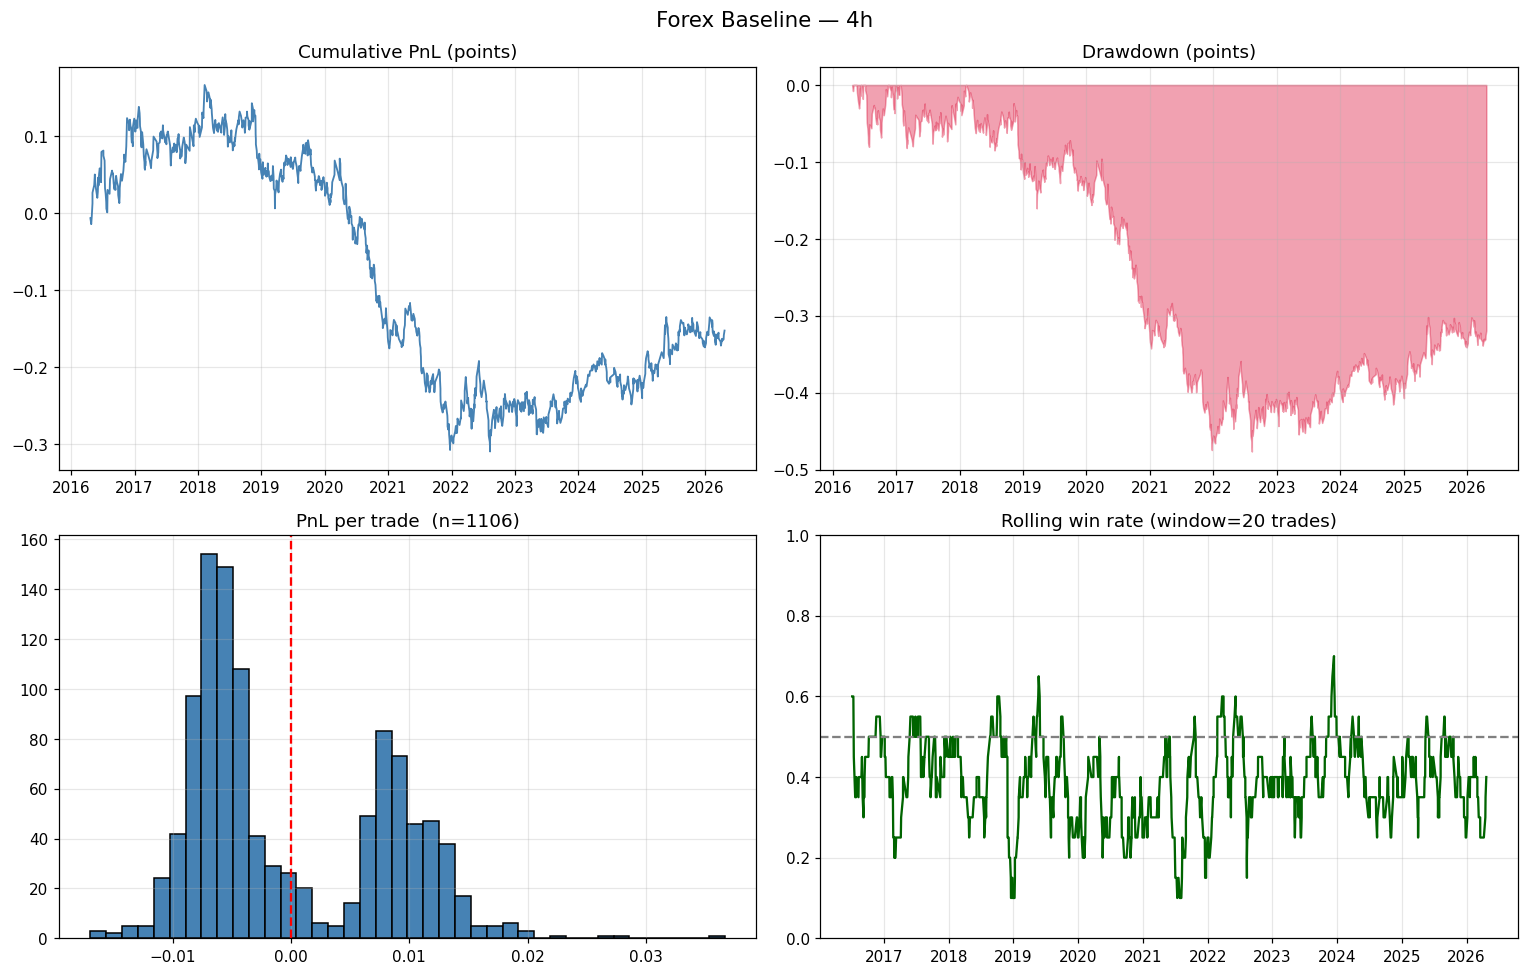

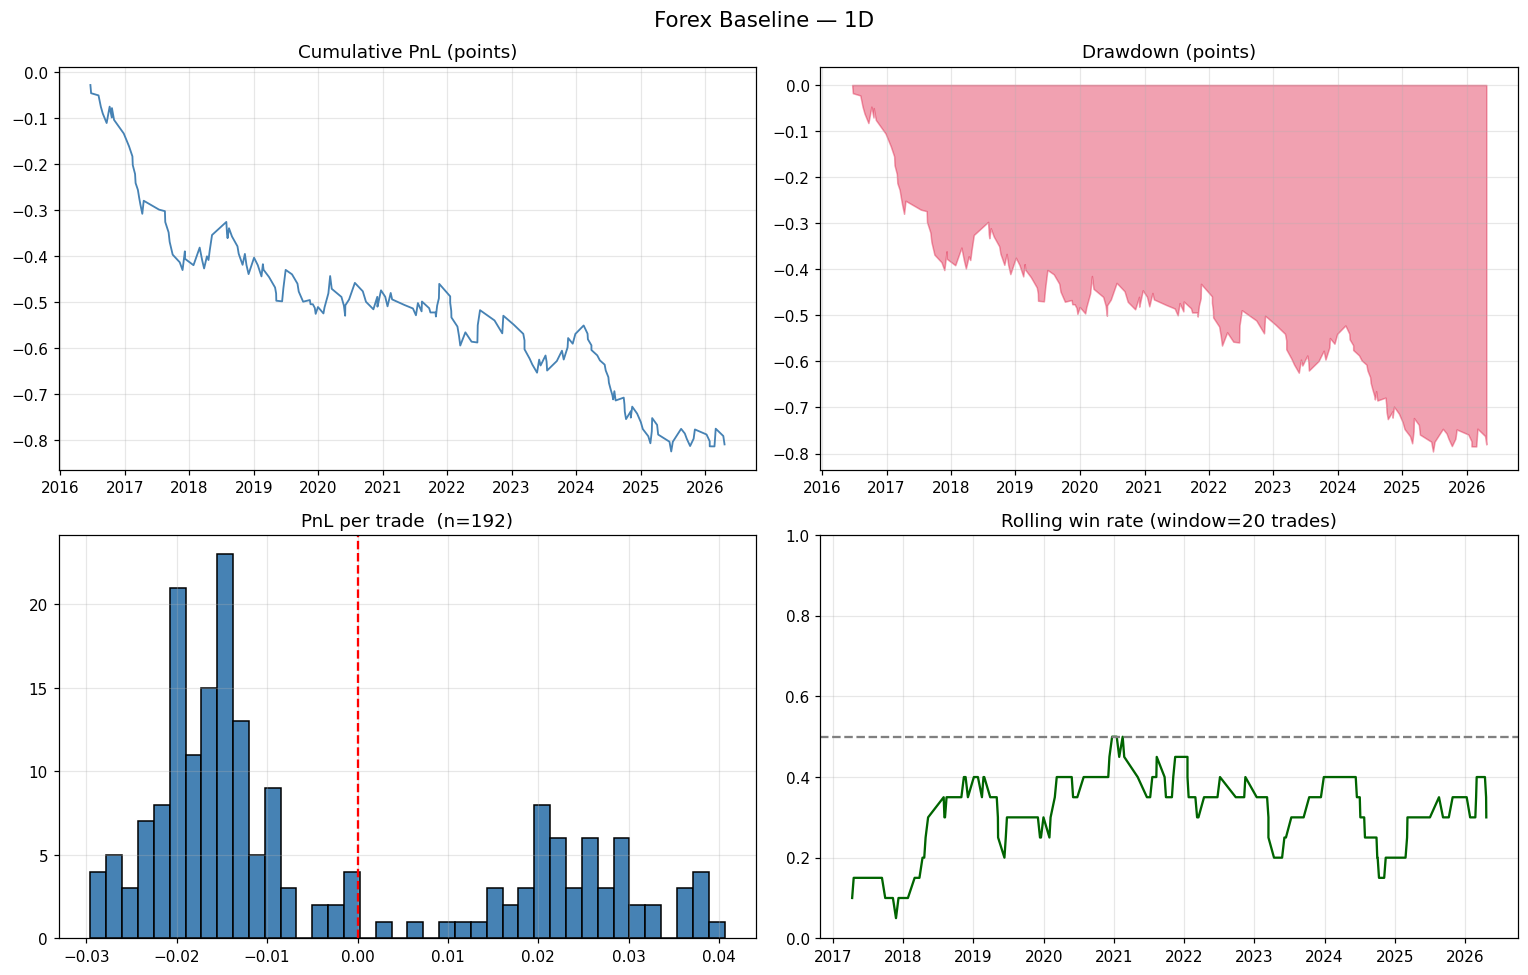

In [7]:
for tf, portfolio in baseline_portfolio["forex"].items():
    if portfolio.trades.empty:
        print(f"  {tf}: no trades — skipping")
        continue
    fig = plot_backtest_dashboard(portfolio, title=f"Forex Baseline — {tf}")
    plt.show()

### 3.2 B3 — baseline across timeframes

Same layout for B3 (Bovespa) assets (WDO / WIN futures).

In [8]:
print("Portfolio metrics — B3 (all assets combined, per timeframe):")
display(metrics_comparison(baseline_portfolio["b3"]))

print("\nPer-asset breakdown by timeframe:")
for tf, asset_results in baseline_per_asset["b3"].items():
    print(f"\n  {tf}:")
    detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
    display(
        pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ]
    )

Portfolio metrics — B3 (all assets combined, per timeframe):


,1min,5min,15min,30min
num_trades,"31,989.0000","6,247.0000","2,100.0000",992.0000
total_pnl,"-31,314.5979","14,746.2696","-3,645.4576","-4,467.3764"
win_rate,0.3868,0.3972,0.3852,0.4002
profit_factor,0.9828,1.0182,0.9929,0.9867
expectancy,-0.9789,2.3605,-1.7359,-4.5034
max_drawdown,"-56,858.8929","-19,256.0384","-40,835.9753","-27,661.8280"
sharpe_daily,-0.3635,0.1579,-0.0374,-0.0509
sharpe_per_trade,-0.9325,0.4390,-0.1033,-0.1362
p_value,0.3511,0.6607,0.9177,0.8916



Per-asset breakdown by timeframe:

  1min:


,WDO,WIN
num_trades,"16,144.0000","15,845.0000"
total_pnl,"-1,450.5979","-29,864.0000"
sharpe_daily,-0.4987,-0.3495
profit_factor,0.9736,0.9831
max_drawdown,"-2,380.4684","-55,155.6429"



  5min:


,WDO,WIN
num_trades,"3,119.0000","3,128.0000"
total_pnl,-580.0161,"15,326.2857"
sharpe_daily,-0.1974,0.1645
profit_factor,0.9760,1.0195
max_drawdown,"-1,564.9219","-19,641.0000"



  15min:


,WDO,WIN
num_trades,"1,044.0000","1,056.0000"
total_pnl,"-2,185.4576","-1,460.0000"
sharpe_daily,-0.7718,-0.0152
profit_factor,0.8577,0.9971
max_drawdown,"-2,187.4726","-39,677.2857"



  30min:


,WDO,WIN
num_trades,516.0000,476.0000
total_pnl,"1,449.9808","-5,917.3571"
sharpe_daily,0.5371,-0.0664
profit_factor,1.1560,0.9819
max_drawdown,-919.0154,"-29,615.6429"


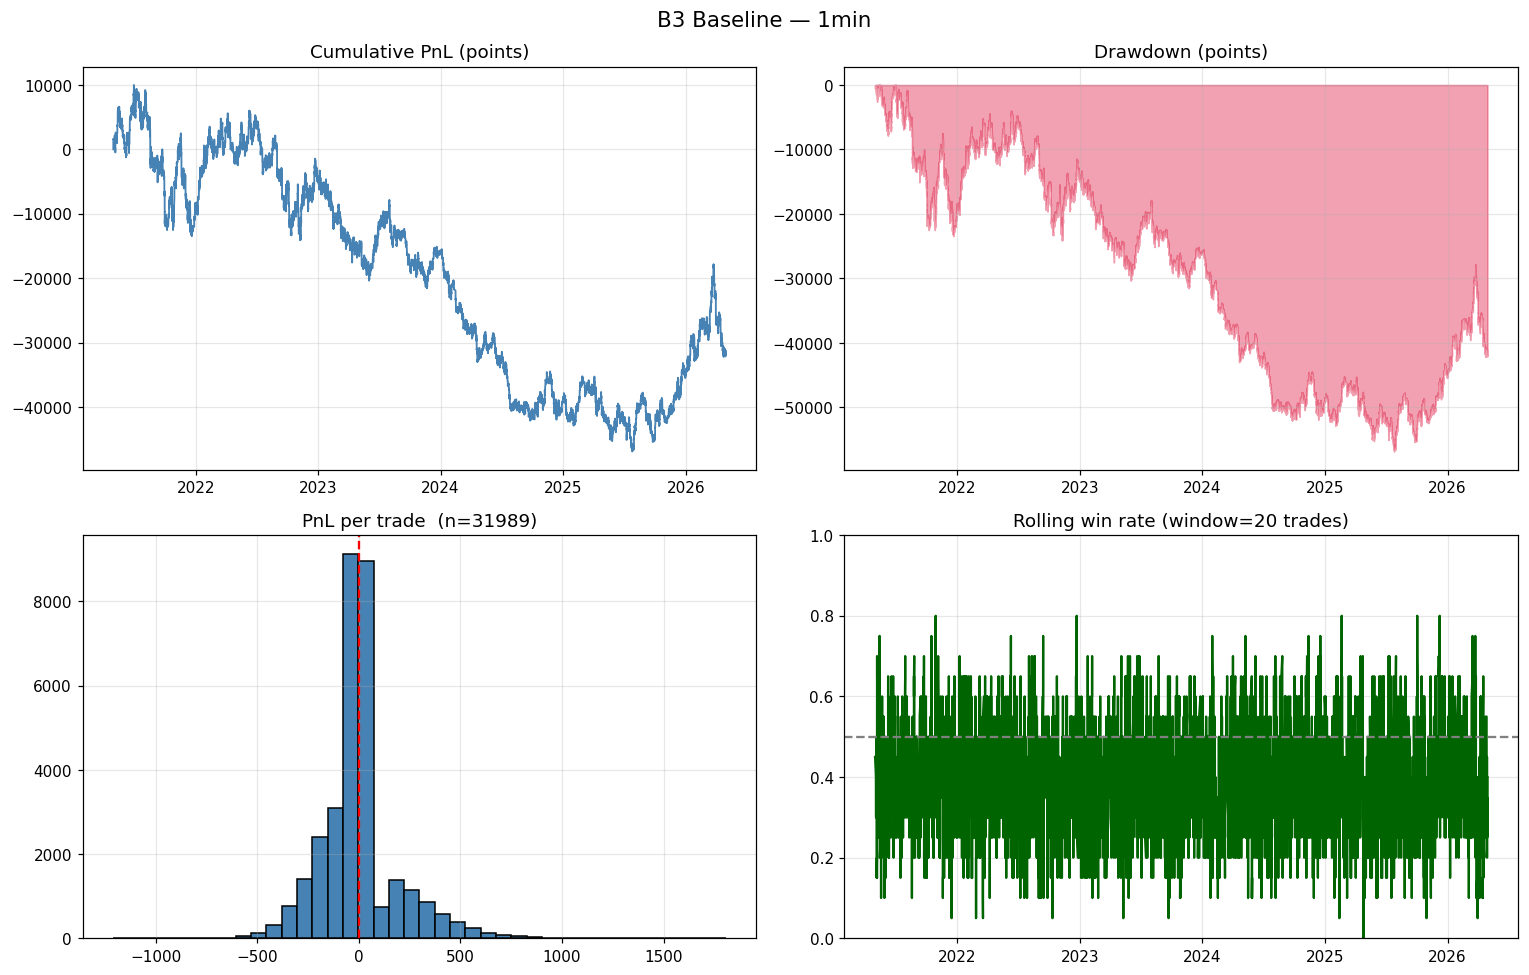

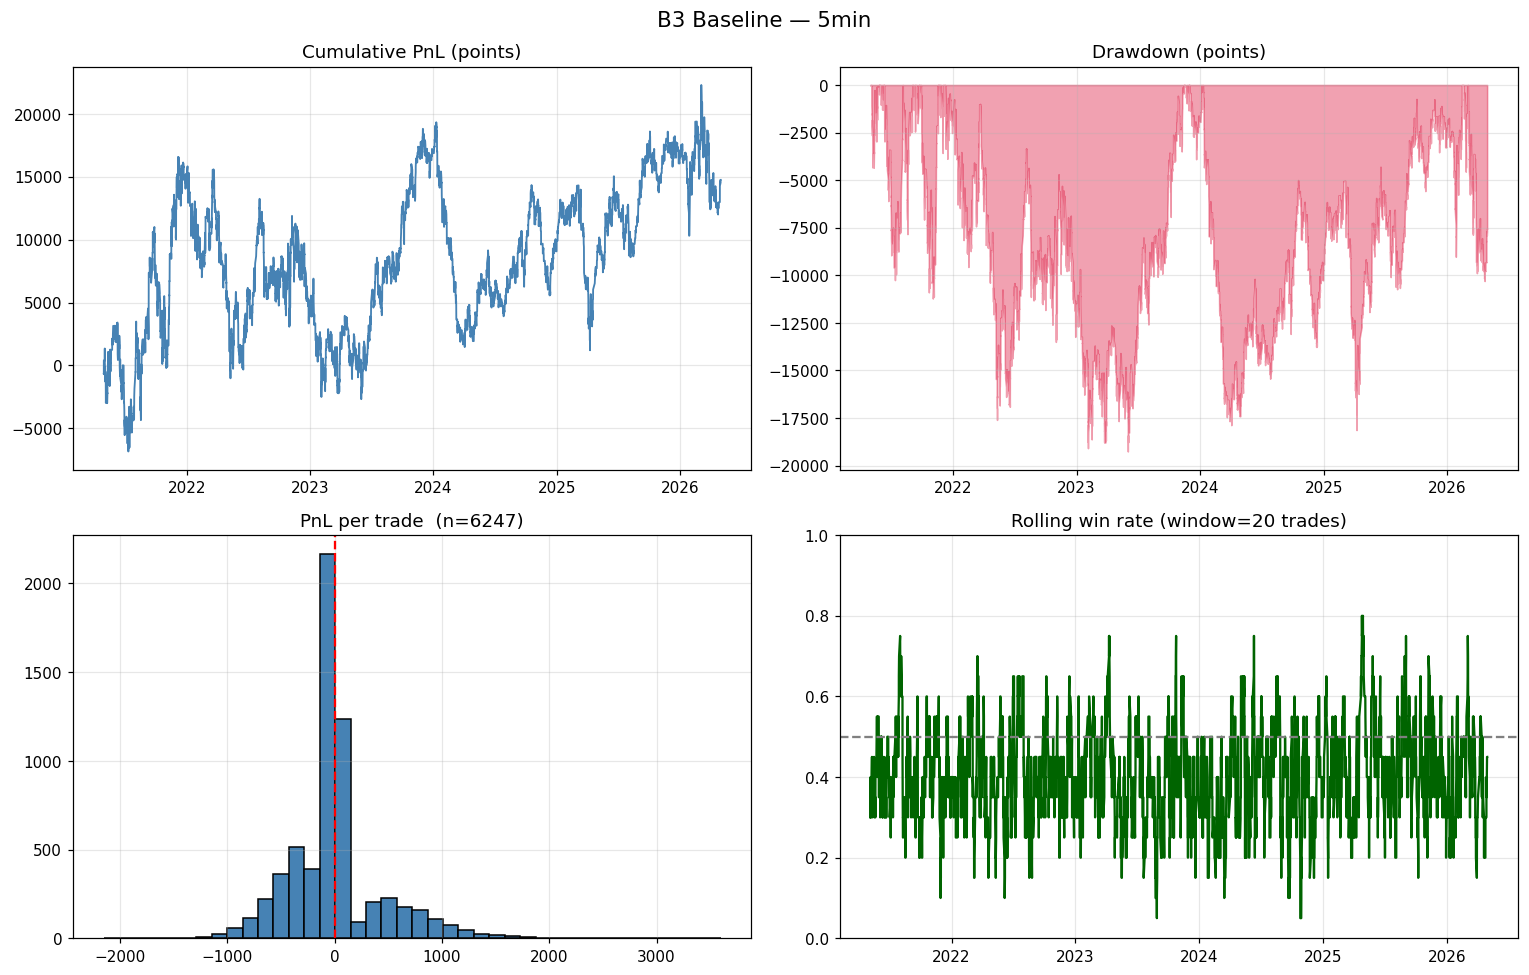

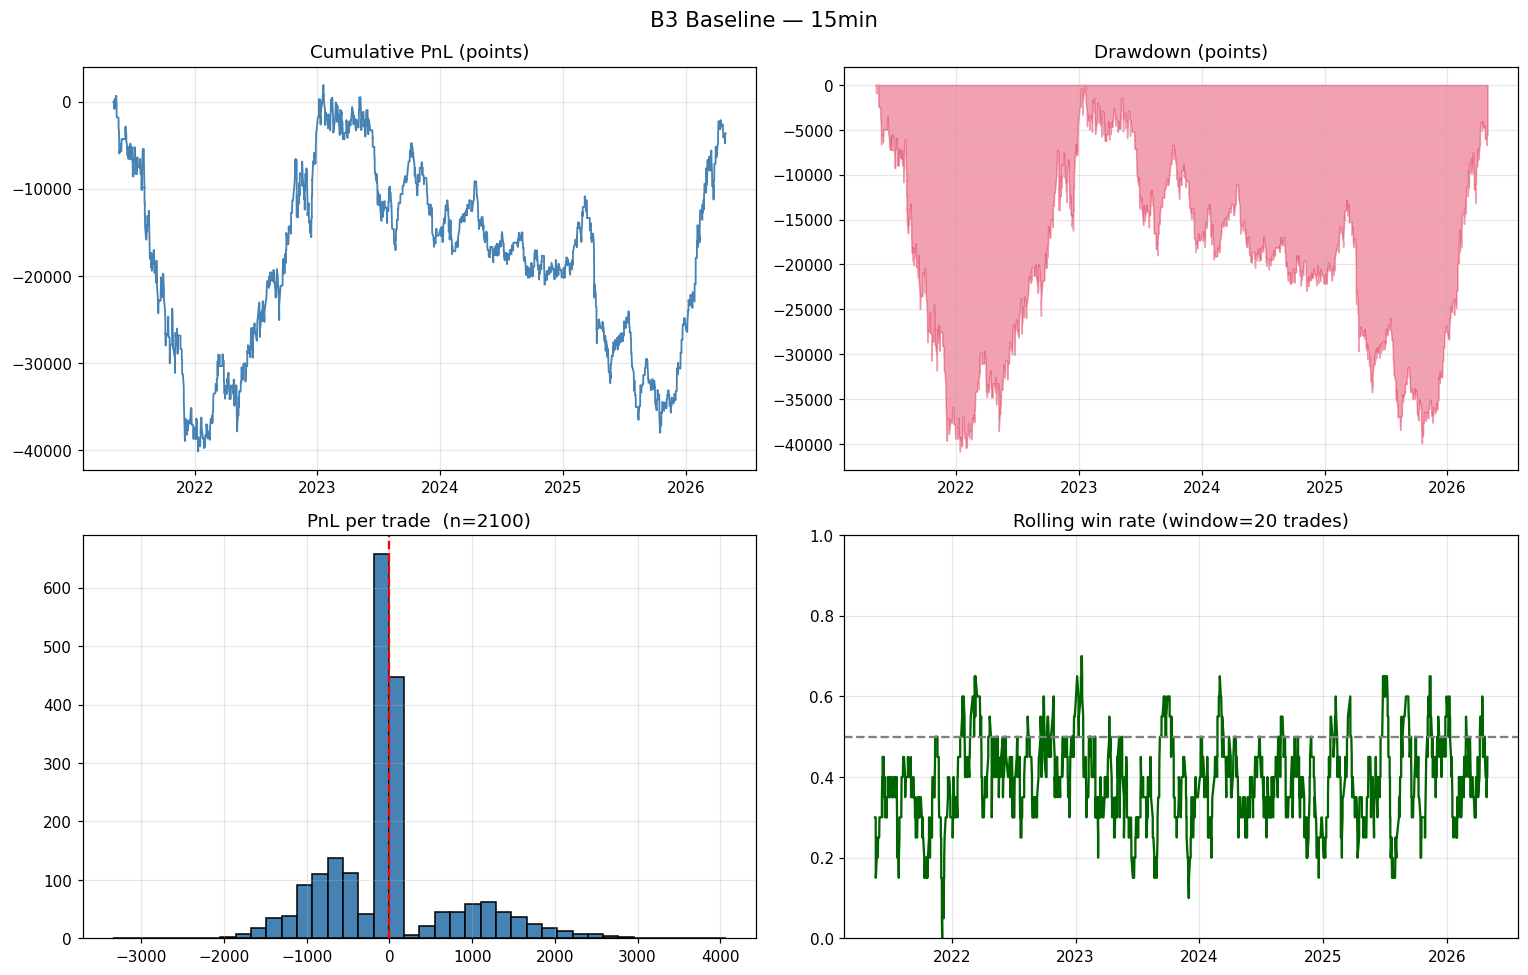

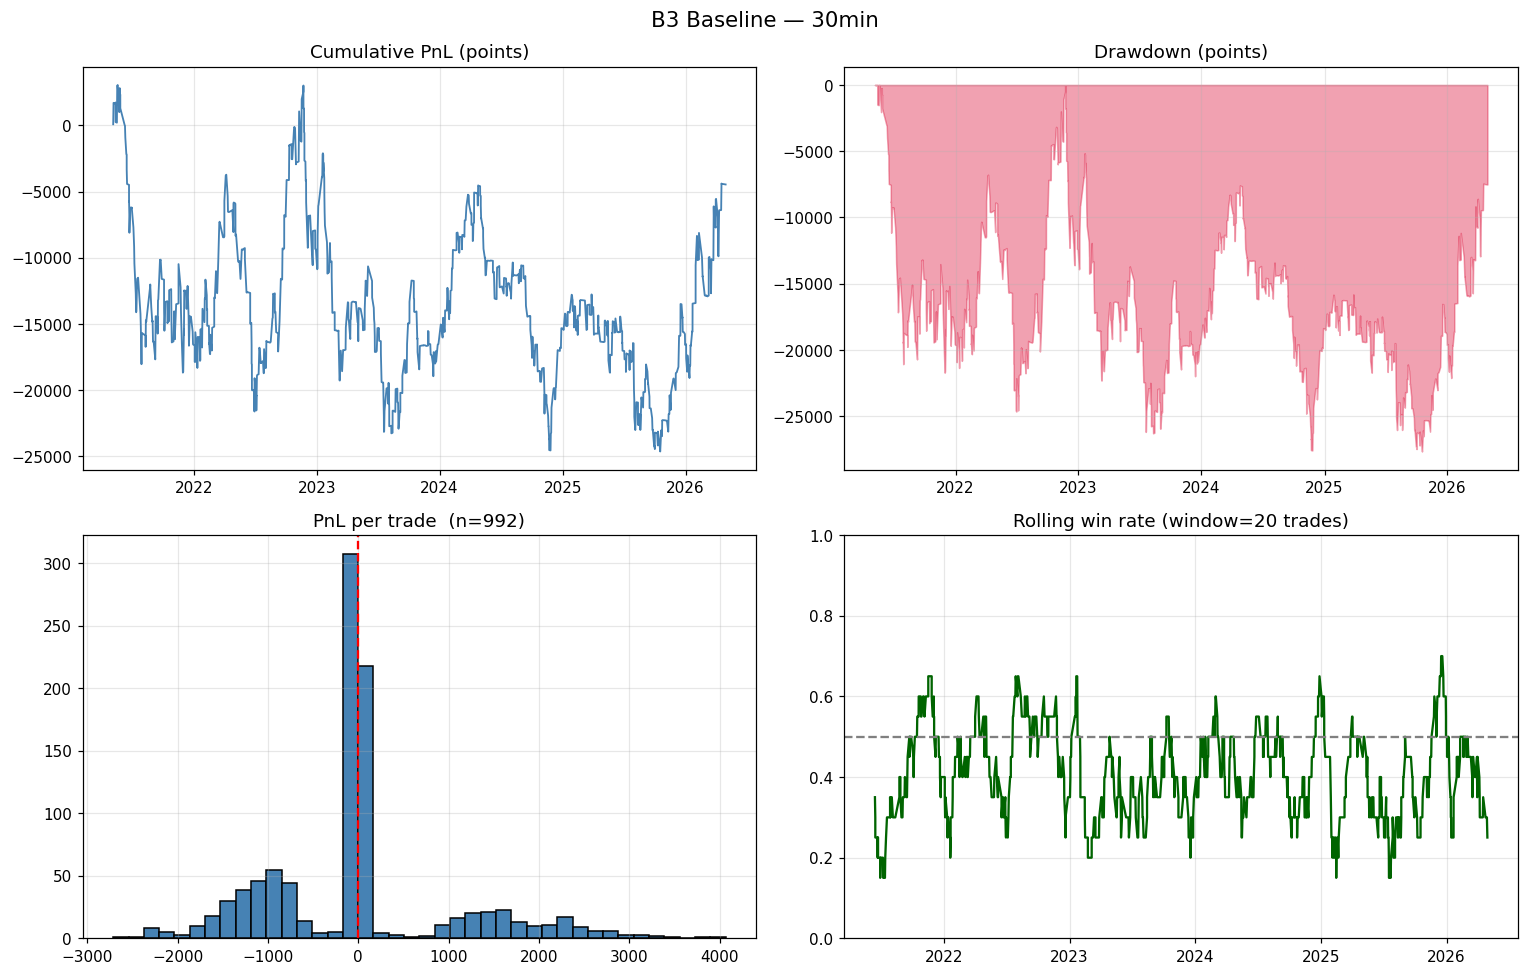

In [9]:
for tf, portfolio in baseline_portfolio["b3"].items():
    if portfolio.trades.empty:
        print(f"  {tf}: no trades — skipping")
        continue
    fig = plot_backtest_dashboard(portfolio, title=f"B3 Baseline — {tf}")
    plt.show()

## 4. Walk-Forward Optimization

Each (group, timeframe) pair runs a separate WFO with `n_splits=5` equal folds.
Inside each fold:
- **In-sample** (75 %): grid-search parameters to maximise daily Sharpe.
- **Out-of-sample** (25 %): apply chosen parameters on unseen data.

OOS equity curves from all assets in the group are stitched chronologically,
giving an honest multi-asset out-of-sample picture per timeframe.

In [10]:
param_grid = {
    "fast":        [5, 10, 20, 30, 50],
    "slow":        [40, 60, 100, 150, 200],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
    "tp_atr_mult": [1.5, 2.0, 3.0, 4.0, 5.0],
}


def build_combined_wfo(wfo_per_asset_tf):
    """Merge per-asset WFOResults into a single combined WFOResult."""
    _oos_frames = []
    for asset, wfo in wfo_per_asset_tf.items():
        if not wfo.oos_trades.empty:
            t = wfo.oos_trades.copy()
            t.insert(0, "asset", asset)
            _oos_frames.append(t)
    if not _oos_frames:
        return WFOResult(
            windows=pd.DataFrame(),
            oos_equity=pd.Series(dtype=float),
            oos_trades=pd.DataFrame(),
        )
    combined_oos = (
        pd.concat(_oos_frames, ignore_index=True)
        .sort_values("exit_time")
        .reset_index(drop=True)
    )
    oos_equity = pd.Series(
        combined_oos["pnl_points"].cumsum().values,
        index=pd.to_datetime(combined_oos["exit_time"].values),
        name="equity_points",
    )
    sample_wfo = next(iter(wfo_per_asset_tf.values()))
    fold_rows = []
    if "fold" in combined_oos.columns and not sample_wfo.windows.empty:
        fold_nums = sorted(combined_oos["fold"].unique())
        avg_deg = {}
        for fn in fold_nums:
            degs = []
            for wfo in wfo_per_asset_tf.values():
                if wfo.windows.empty or "degradation_ratio" not in wfo.windows.columns:
                    continue
                fw = wfo.windows[wfo.windows["fold"] == fn]
                if not fw.empty and pd.notna(fw.iloc[0]["degradation_ratio"]):
                    degs.append(float(fw.iloc[0]["degradation_ratio"]))
            avg_deg[fn] = float(np.nanmean(degs)) if degs else np.nan
        for fold_num in fold_nums:
            _ft = combined_oos[combined_oos["fold"] == fold_num].sort_values("exit_time")
            _feq = pd.Series(
                _ft["pnl_points"].cumsum().values,
                index=pd.to_datetime(_ft["exit_time"].values),
            )
            _fm = compute_metrics(_PortfolioResult(_ft, _feq))
            _bnd = sample_wfo.windows[sample_wfo.windows["fold"] == fold_num].iloc[0]
            param_cols = {k: v for k, v in _bnd.items() if str(k).startswith("param_")}
            fold_rows.append({
                "fold": fold_num,
                "is_start": _bnd["is_start"],  "is_end": _bnd["is_end"],
                "oos_start": _bnd["oos_start"], "oos_end": _bnd["oos_end"],
                "oos_pnl": _fm["total_pnl"],    "oos_sharpe": _fm["sharpe_daily"],
                "oos_profit_factor": _fm["profit_factor"],
                "oos_win_rate": _fm["win_rate"], "oos_trades": _fm["num_trades"],
                "degradation_ratio": avg_deg.get(fold_num, np.nan),
                **param_cols,
            })
    return WFOResult(
        windows=pd.DataFrame(fold_rows),
        oos_equity=oos_equity,
        oos_trades=combined_oos,
    )


# Outer parallelism: one worker per (group, tf, asset) cell — each loads its
# own CSV.  Inner parallelism (across folds) is left at 1 because the outer
# loop typically already saturates the CPU.
flat_wfo = run_wfo_grid(
    group_tfs,
    param_grid=param_grid,
    n_splits=5,
    oos_ratio=0.25,
    strategy_cls=SMACrossoverStrategy,
    params_cls=StrategyParams,
    n_jobs=N_JOBS,
    inner_n_jobs=1,
)
wfo_per_asset = reshape_grid_results(flat_wfo)
wfo_combined = {
    g: {tf: build_combined_wfo(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in wfo_per_asset.items()
}

for group in wfo_combined:
    for tf, wfo in wfo_combined[group].items():
        print(f"{group:5s}  {tf:6s}  {len(wfo.oos_trades):>6,} OOS trades")


  WFO [17/17]


b3     1min     5,416 OOS trades
b3     5min     1,384 OOS trades
b3     15min      252 OOS trades
b3     30min      154 OOS trades
forex  1h         983 OOS trades
forex  4h         201 OOS trades
forex  1D          38 OOS trades


### 4.1 Forex — WFO out-of-sample results

OOS portfolio metrics — Forex (per timeframe):


,1h,4h,1D
num_trades,983.0000,201.0000,38.0000
total_pnl,-0.0718,-0.0037,0.0641
win_rate,0.4710,0.4826,0.4474
profit_factor,0.9499,0.9936,1.3309
expectancy,-0.0001,-0.0000,0.0017
max_drawdown,-0.2417,-0.1097,-0.0770
sharpe_daily,-0.1753,-0.0305,0.1327
sharpe_per_trade,-0.6199,-0.0391,0.7273
p_value,0.5353,0.9688,0.4670


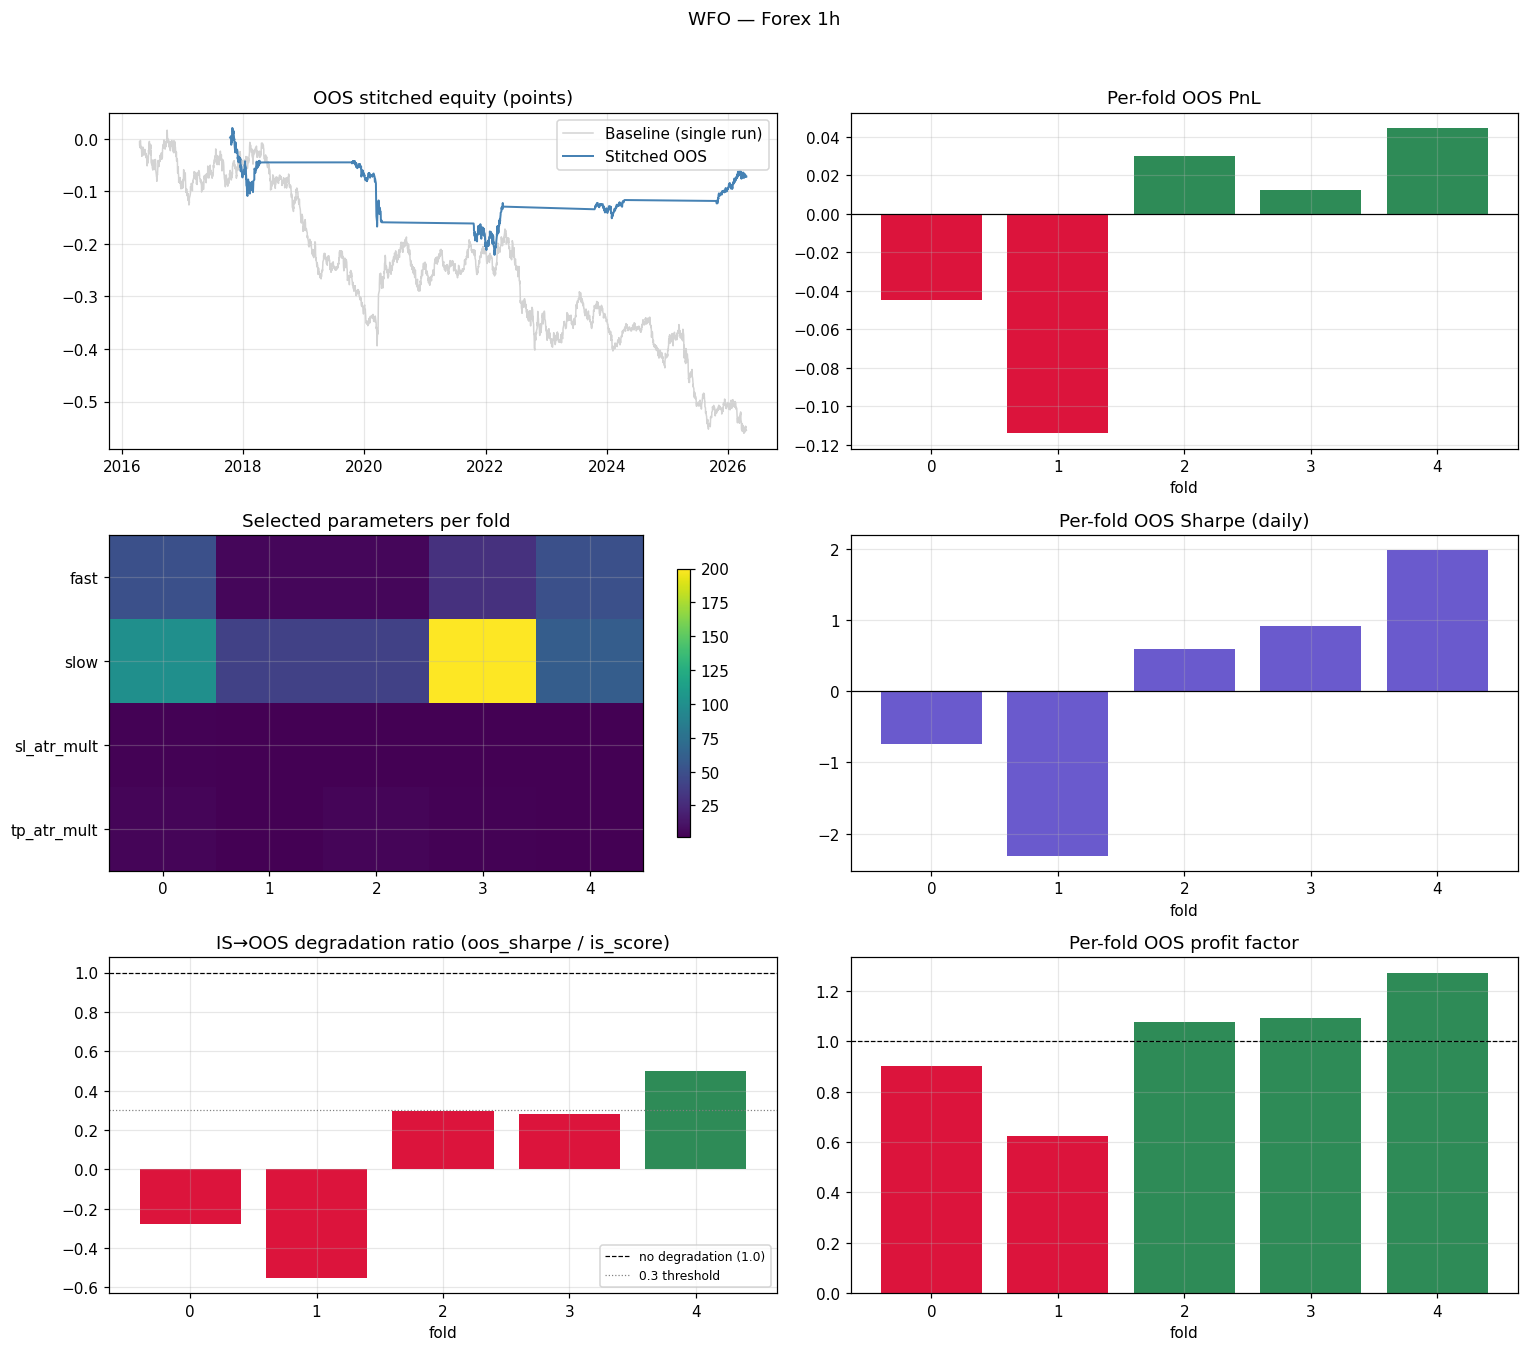

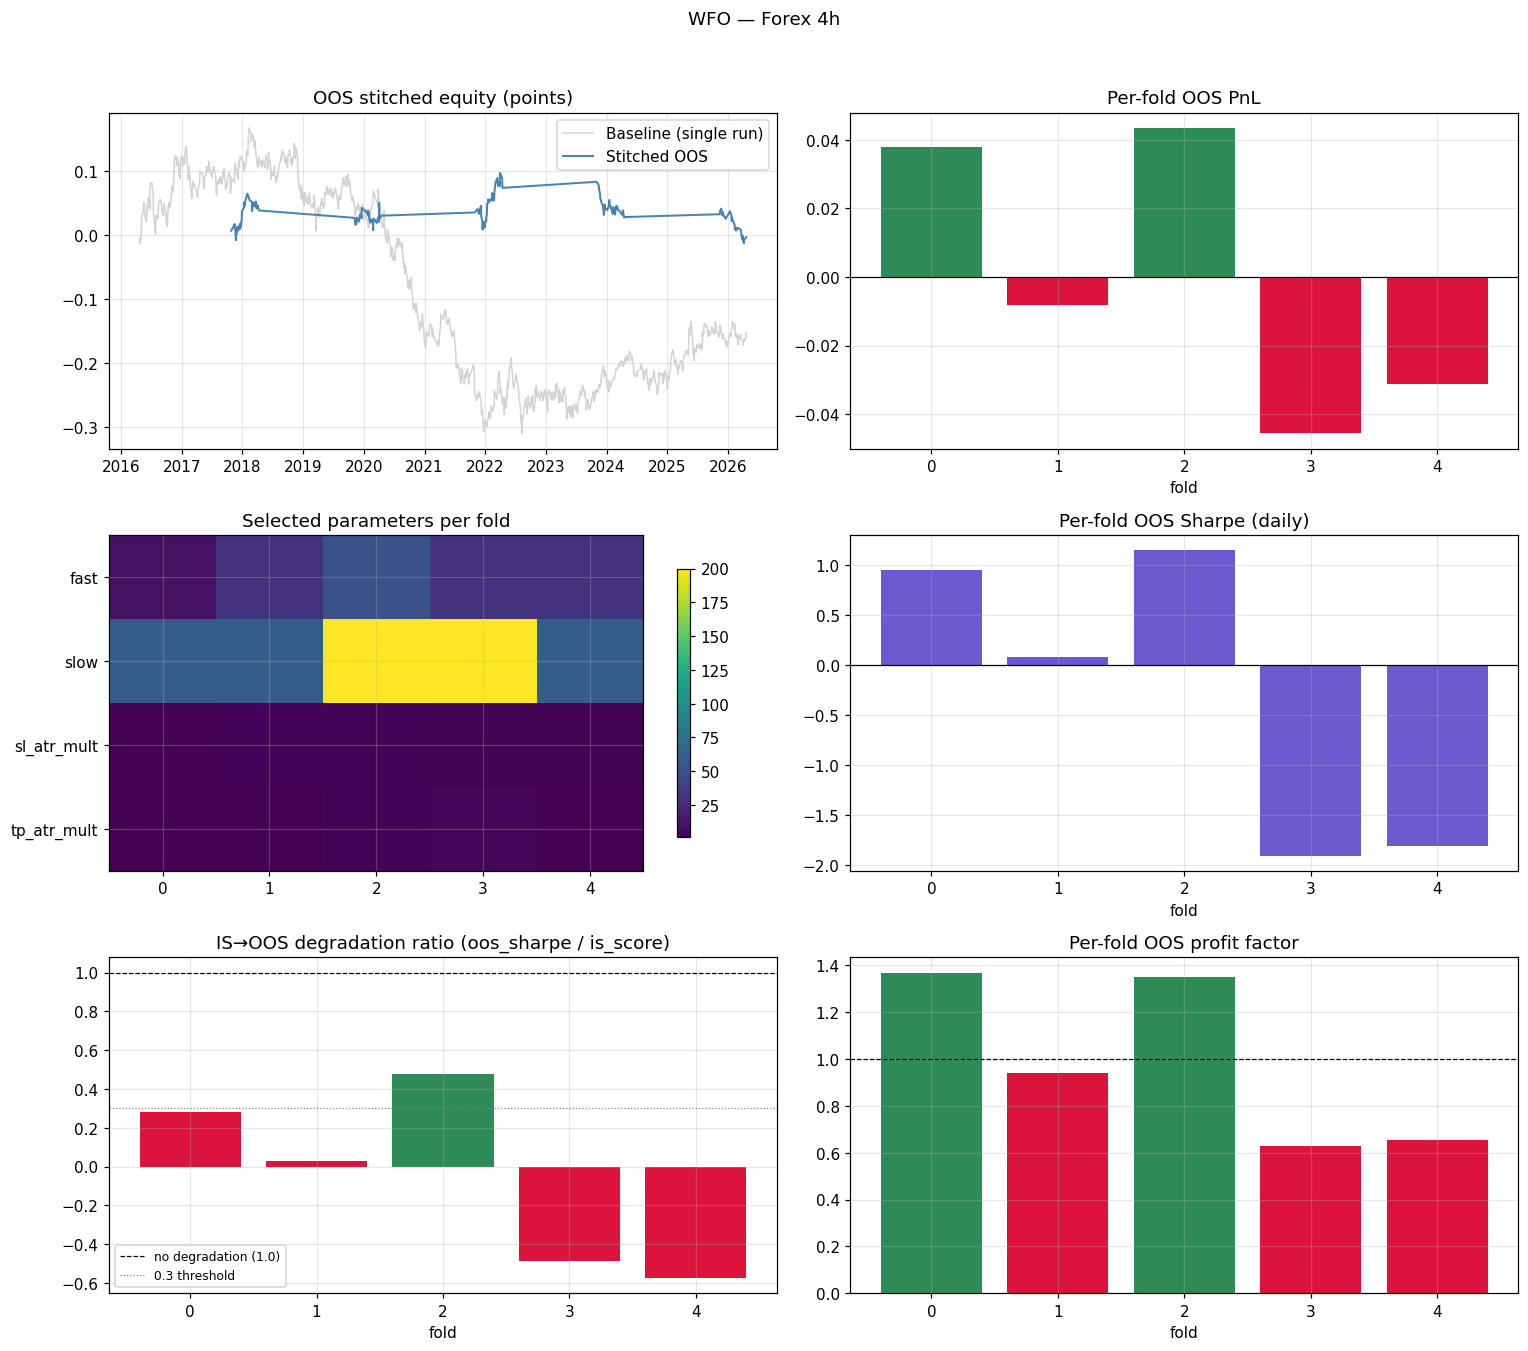

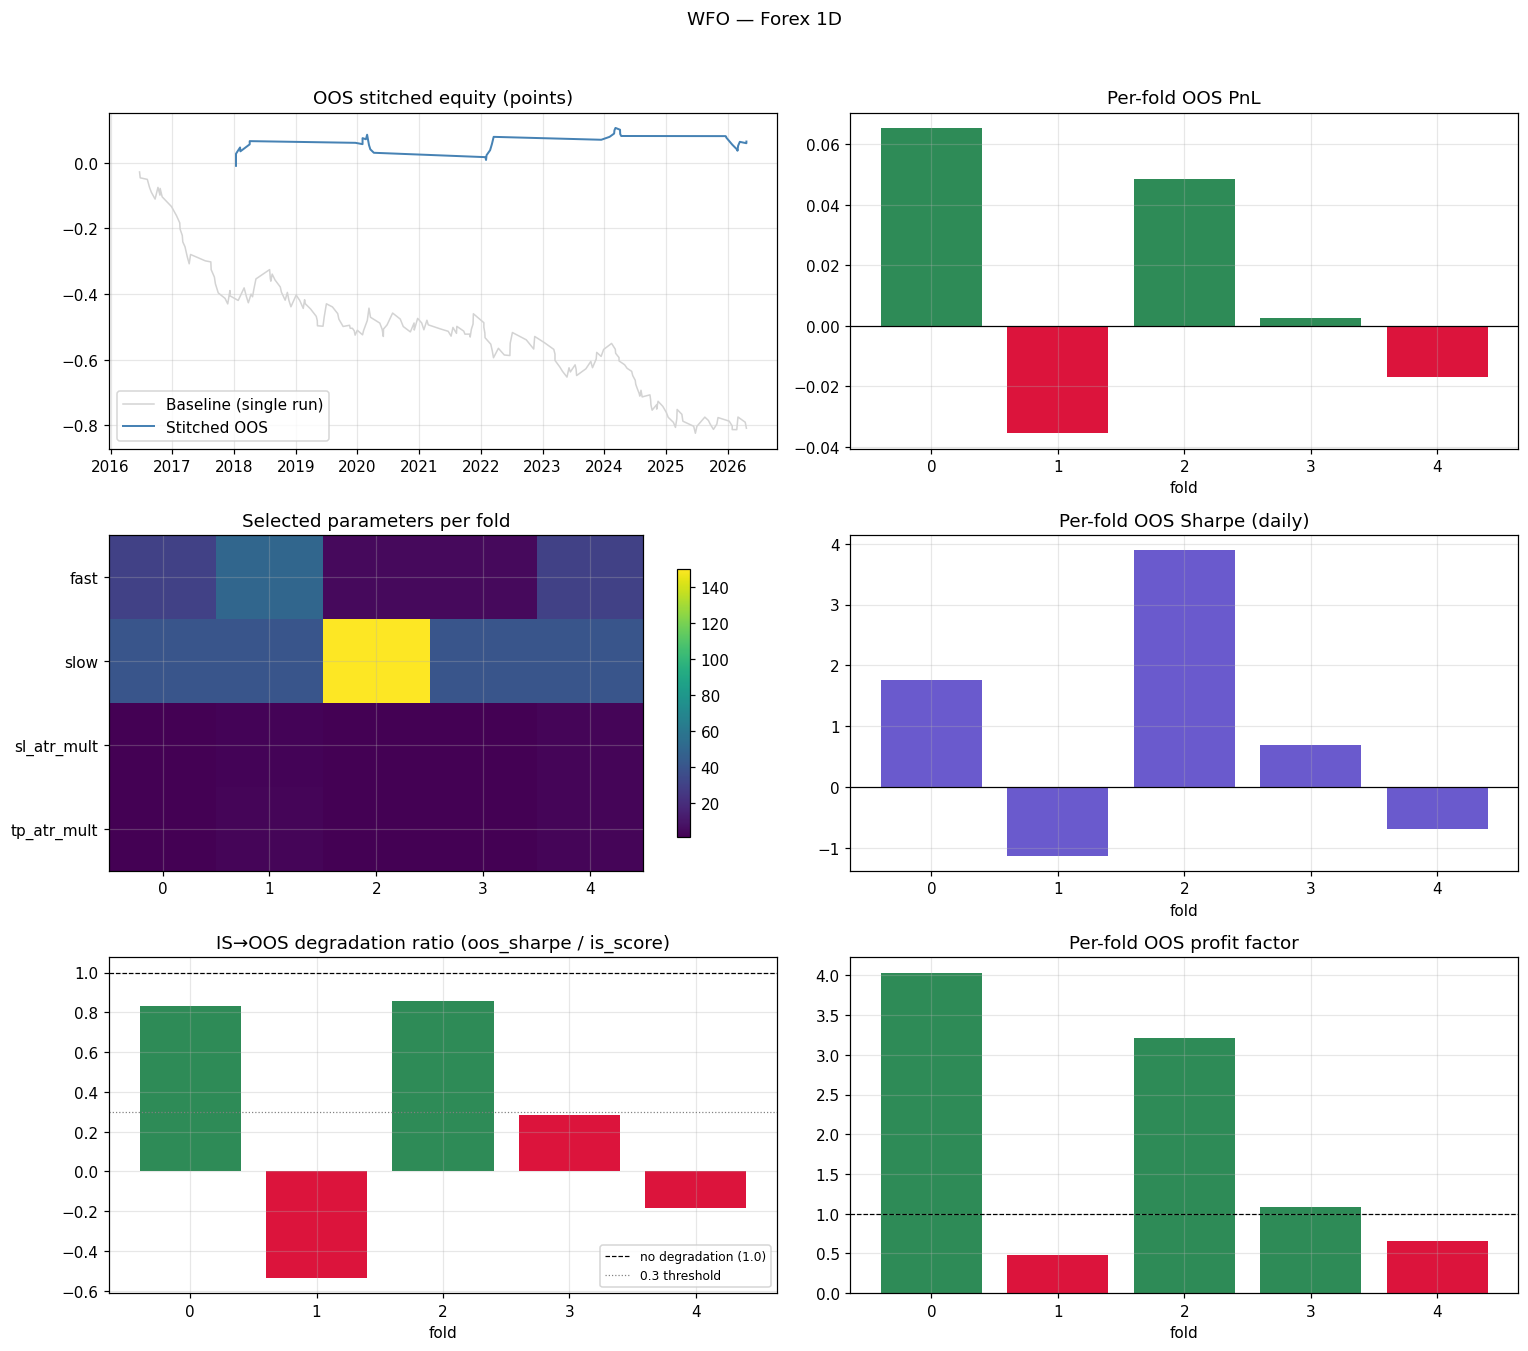

In [11]:
forex_oos_portfolios = {
    tf: _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
    for tf, wfo in wfo_combined["forex"].items()
    if not wfo.oos_trades.empty
}
print("OOS portfolio metrics — Forex (per timeframe):")
display(metrics_comparison(forex_oos_portfolios))

for tf, wfo in wfo_combined["forex"].items():
    if wfo.oos_trades.empty:
        continue
    baseline_eq = baseline_portfolio["forex"][tf].equity
    fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
    fig.suptitle(f"WFO — Forex {tf}", y=1.02)
    plt.show()

### 4.2 B3 — WFO out-of-sample results

OOS portfolio metrics — B3 (per timeframe):


,1min,5min,15min,30min
num_trades,"5,416.0000","1,384.0000",252.0000,154.0000
total_pnl,"12,251.3107","-30,349.5653","-1,738.5775","14,510.7573"
win_rate,0.5205,0.4523,0.4365,0.5909
profit_factor,1.0348,0.8111,0.9555,1.8114
expectancy,2.2621,-21.9289,-6.8991,94.2257
max_drawdown,"-15,042.0505","-34,379.6571","-6,955.4208","-3,890.8109"
sharpe_daily,0.3243,-0.8497,0.0423,0.8926
sharpe_per_trade,0.7718,-2.1786,-0.2154,2.1386
p_value,0.4402,0.0294,0.8294,0.0325


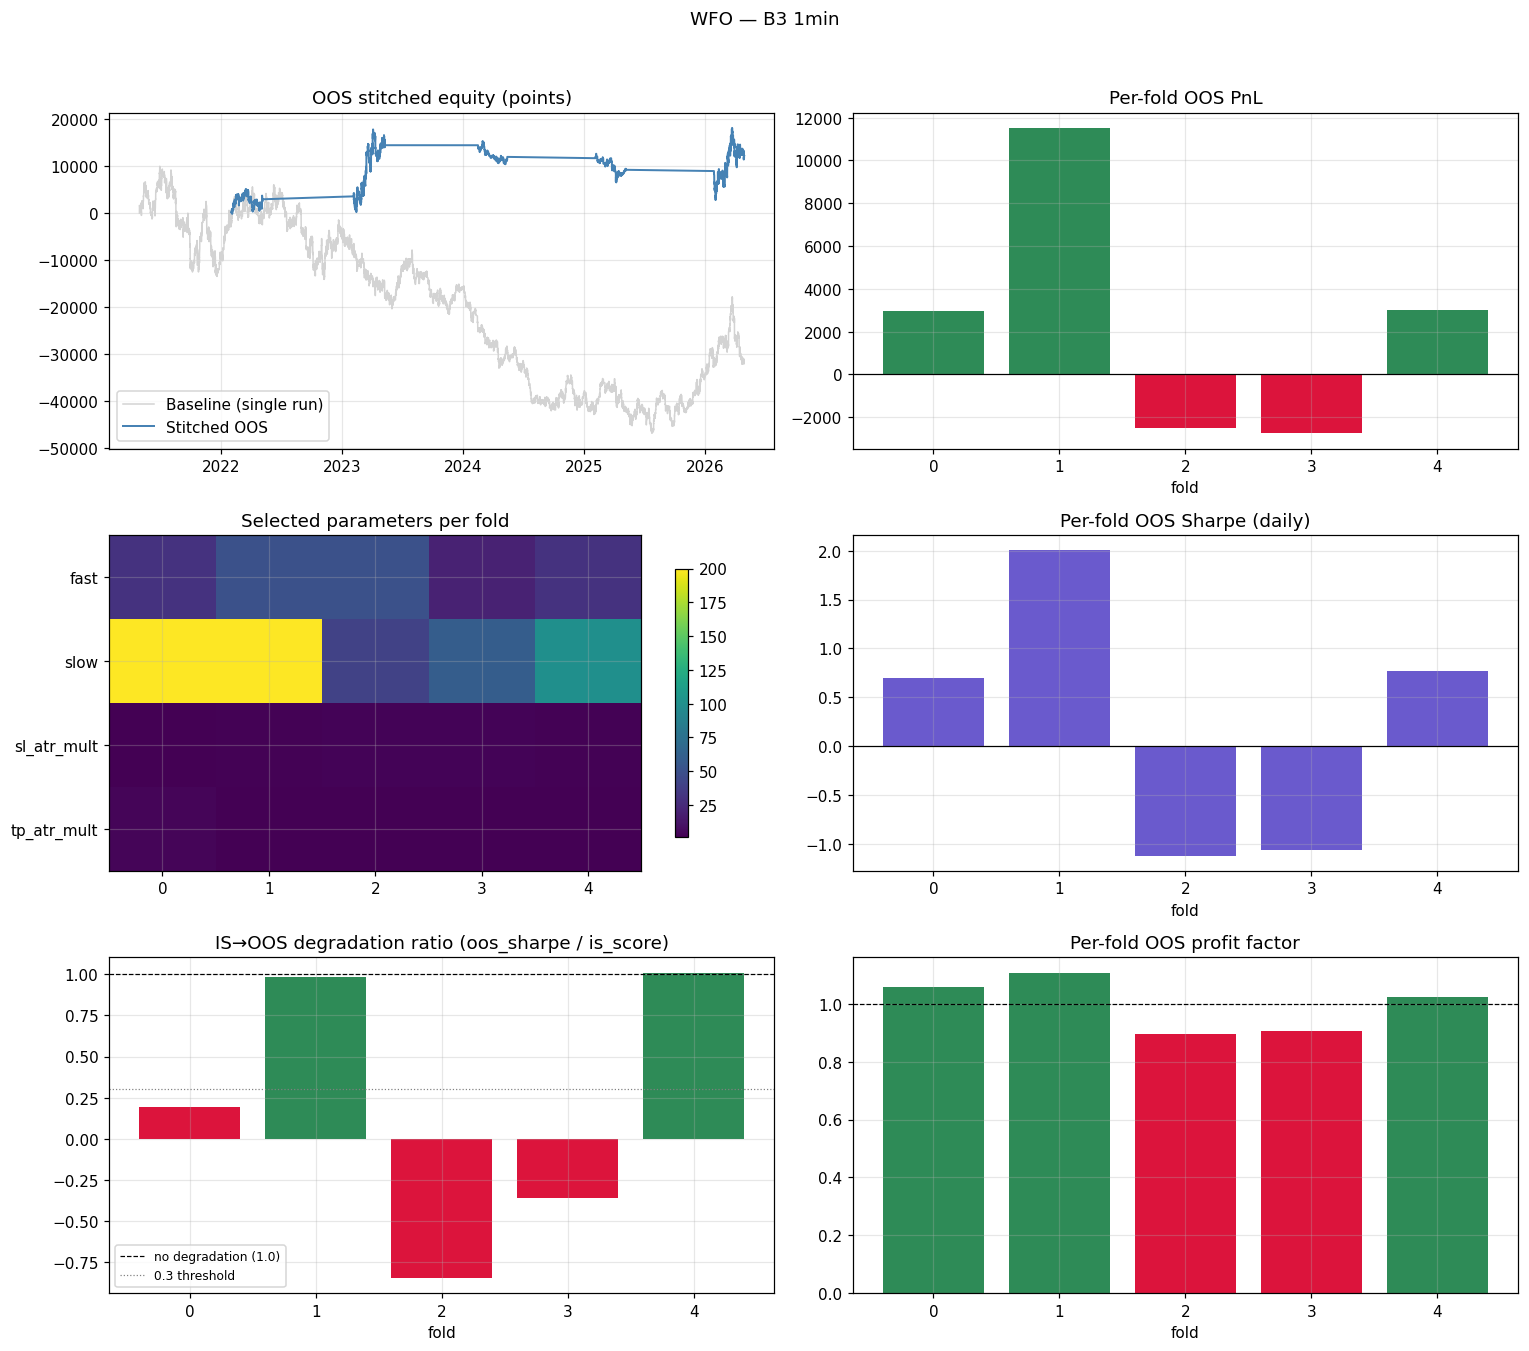

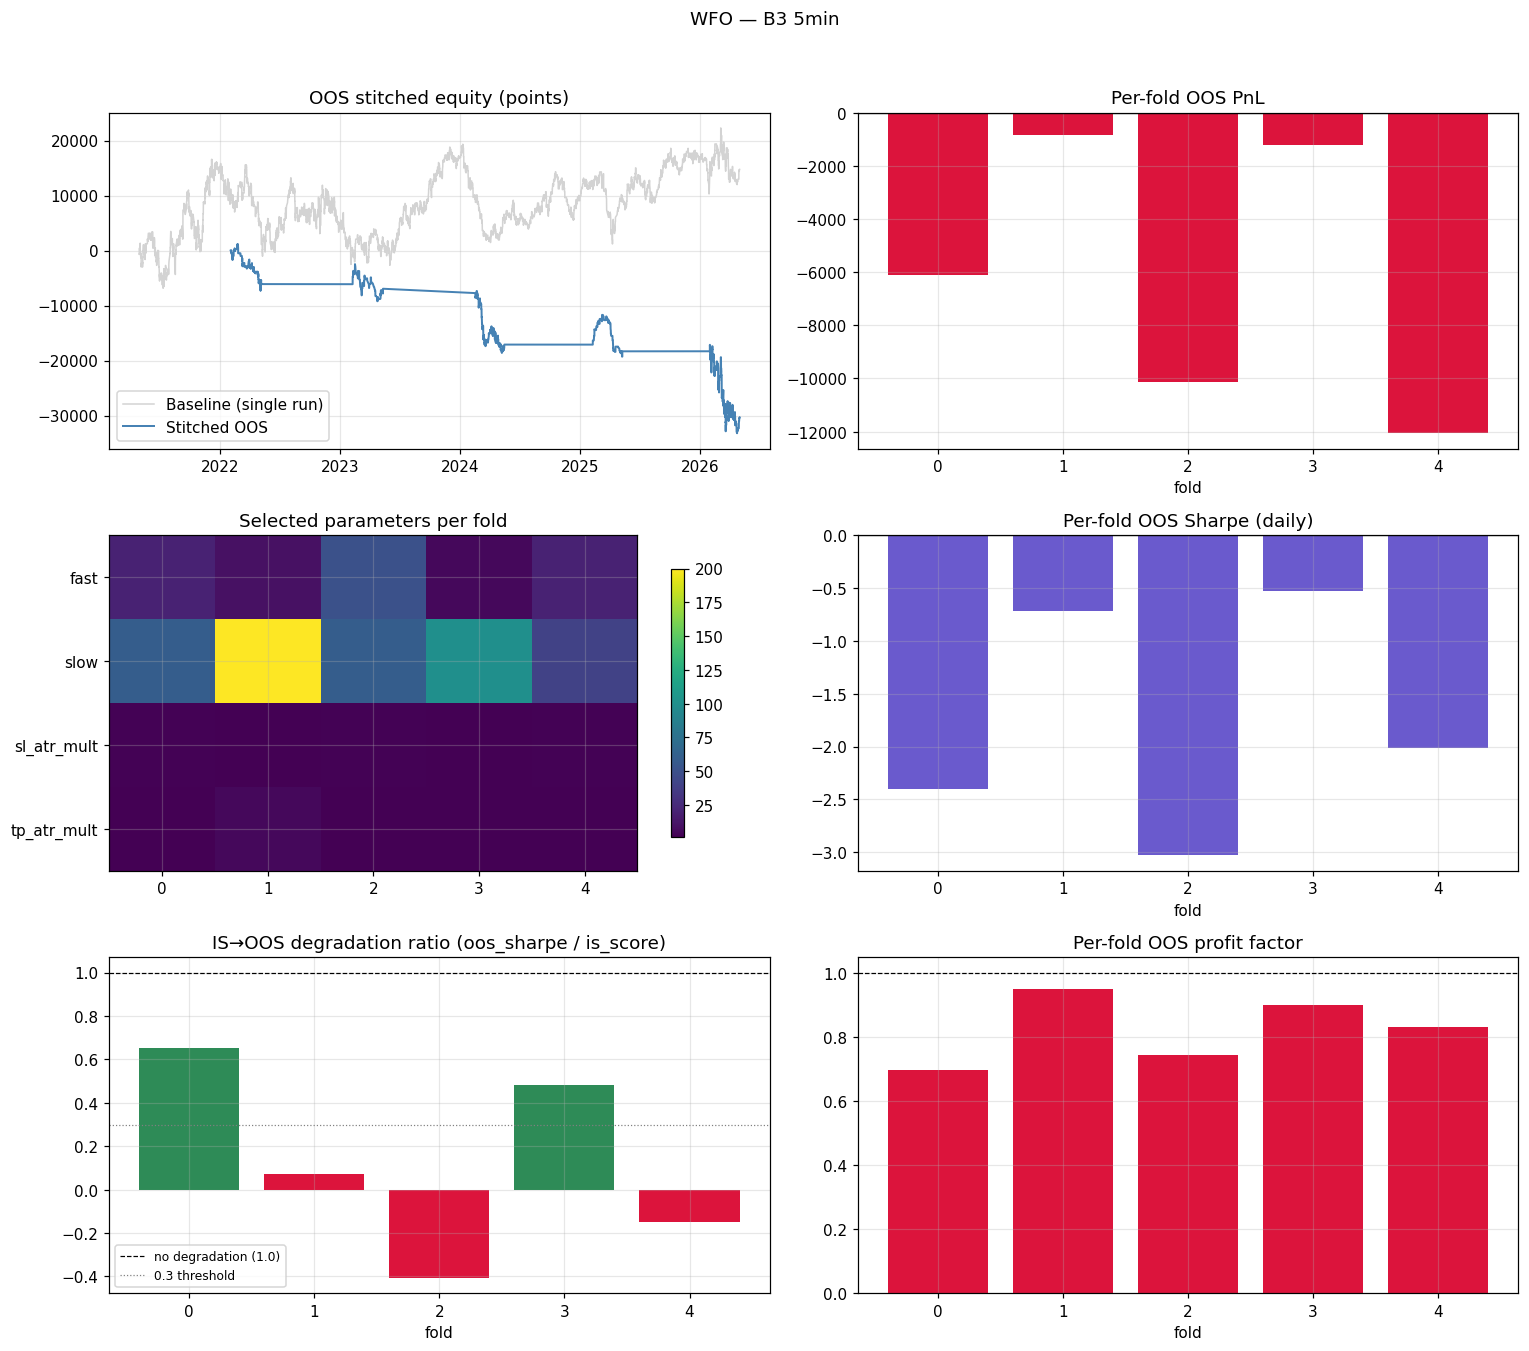

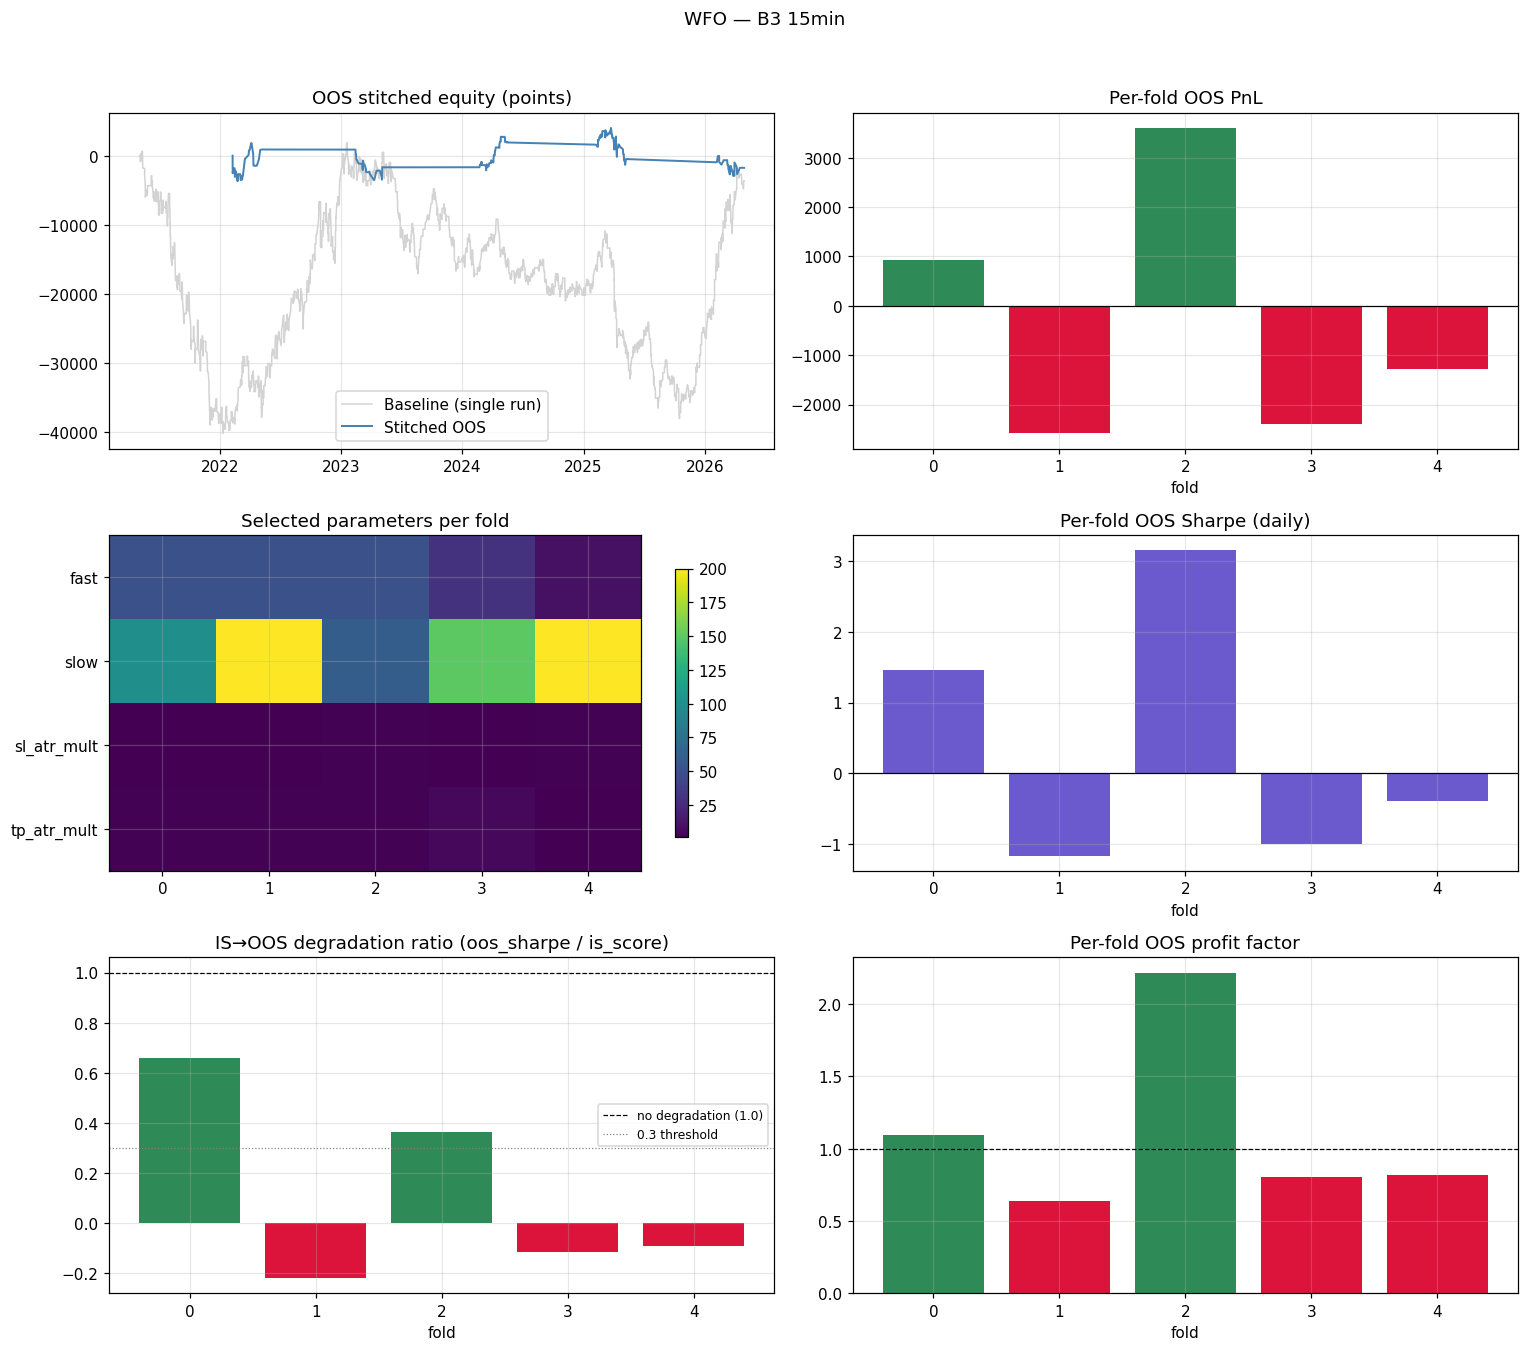

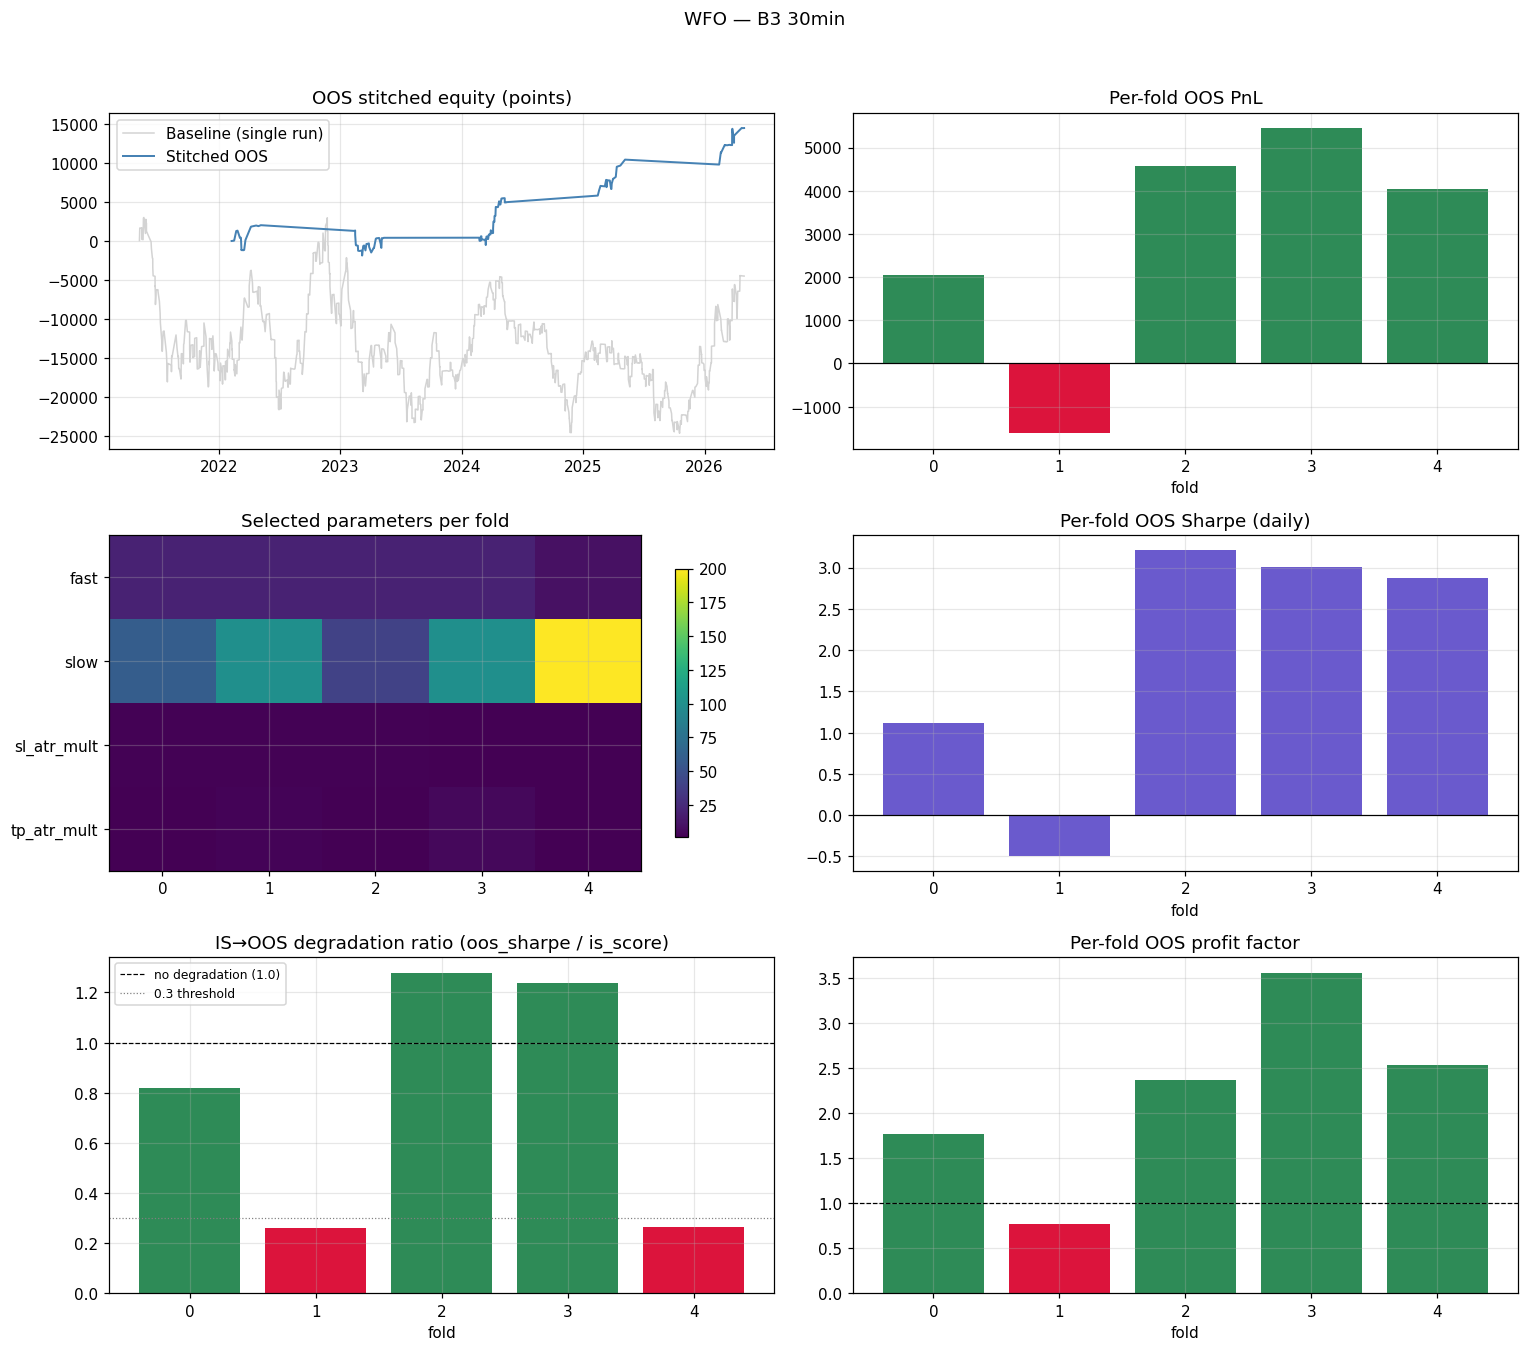

In [12]:
b3_oos_portfolios = {
    tf: _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
    for tf, wfo in wfo_combined["b3"].items()
    if not wfo.oos_trades.empty
}
print("OOS portfolio metrics — B3 (per timeframe):")
display(metrics_comparison(b3_oos_portfolios))

for tf, wfo in wfo_combined["b3"].items():
    if wfo.oos_trades.empty:
        continue
    baseline_eq = baseline_portfolio["b3"][tf].equity
    fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
    fig.suptitle(f"WFO — B3 {tf}", y=1.02)
    plt.show()

### 4.3 WFO-optimized full-history backtest

For each (group, timeframe), pick the **most frequently selected** parameter
combination across WFO folds as the "best" params, then run a full-history
backtest with those params to see what the strategy would have produced with
consistently re-optimized values.

In [13]:
def pick_best_params(wfo_windows, fallback):
    """Return the most common param combo across WFO folds as StrategyParams."""
    if wfo_windows.empty:
        return fallback
    pcols = [c for c in wfo_windows.columns if c.startswith("param_")]
    tuples = [tuple(row[c] for c in pcols) for _, row in wfo_windows.iterrows()]
    best = Counter(tuples).most_common(1)[0][0]
    kw = {c.replace("param_", ""): v for c, v in zip(pcols, best)}
    for k in ("fast", "slow", "atr_period"):
        if k in kw:
            kw[k] = int(kw[k])
    return StrategyParams(**kw)


# pick the WFO-most-frequent params per (group, tf, asset)
optimized_params = {}
params_by_key = {}
for group, tfs in wfo_per_asset.items():
    optimized_params[group] = {}
    for tf, by_asset in tfs.items():
        optimized_params[group][tf] = {}
        for asset, wfo in by_asset.items():
            p = pick_best_params(wfo.windows, baseline_params)
            optimized_params[group][tf][asset] = p
            params_by_key[(group, tf, asset)] = p

# Re-run backtests in parallel with each cell's optimized params.
from source import run_backtests_with_params
flat_opt = run_backtests_with_params(
    group_tfs,
    params_by_key,
    strategy_cls=SMACrossoverStrategy,
    n_jobs=N_JOBS,
    progress=False,
)
opt_per_asset = reshape_grid_results(flat_opt)
optimized_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in opt_per_asset.items()
}

print("Optimized parameters per group / timeframe / asset:")
for group in optimized_params:
    for tf in GROUP_TIMEFRAMES[group]:
        for asset, p in optimized_params[group][tf].items():
            print(f"  {group:5s} {tf:6s} {asset:8s}  "
                  f"fast={p.fast} slow={p.slow}  sl={p.sl_atr_mult} tp={p.tp_atr_mult}")

print("\nOptimized portfolio metrics — Forex:")
display(metrics_comparison(optimized_portfolio["forex"]))

print("\nOptimized portfolio metrics — B3:")
display(metrics_comparison(optimized_portfolio["b3"]))


Optimized parameters per group / timeframe / asset:
  b3    1min   WDO       fast=30 slow=200  sl=1.0 tp=4.0
  b3    1min   WIN       fast=50 slow=100  sl=2.5 tp=2.0
  b3    5min   WDO       fast=20 slow=60  sl=2.0 tp=1.5
  b3    5min   WIN       fast=10 slow=200  sl=1.5 tp=1.5
  b3    15min  WDO       fast=50 slow=100  sl=1.5 tp=2.0
  b3    15min  WIN       fast=50 slow=100  sl=3.0 tp=1.5
  b3    30min  WDO       fast=20 slow=60  sl=2.5 tp=1.5
  b3    30min  WIN       fast=50 slow=150  sl=1.5 tp=2.0
  forex 1h     EURCAD    fast=50 slow=100  sl=3.0 tp=4.0
  forex 1h     EURUSD    fast=5 slow=40  sl=2.5 tp=2.0
  forex 1h     GBPCHF    fast=10 slow=100  sl=3.0 tp=5.0
  forex 4h     EURCAD    fast=10 slow=60  sl=1.0 tp=1.5
  forex 4h     EURUSD    fast=50 slow=100  sl=3.0 tp=1.5
  forex 4h     GBPCHF    fast=5 slow=150  sl=2.0 tp=2.0
  forex 1D     EURCAD    fast=30 slow=40  sl=1.0 tp=1.5
  forex 1D     EURUSD    fast=30 slow=40  sl=1.5 tp=5.0
  forex 1D     GBPCHF    fast=10 slow=40  sl

,1h,4h,1D
num_trades,"4,192.0000",907.0000,264.0000
total_pnl,0.0862,0.1190,0.3961
win_rate,0.4244,0.4620,0.3485
profit_factor,1.0112,1.0501,1.2620
expectancy,0.0000,0.0001,0.0015
max_drawdown,-0.5812,-0.3540,-0.2366
sharpe_daily,0.0694,0.1603,0.4037
sharpe_per_trade,0.2824,0.6439,1.5237
p_value,0.7776,0.5197,0.1276



Optimized portfolio metrics — B3:


,1min,5min,15min,30min
num_trades,"13,098.0000","4,287.0000",958.0000,629.0000
total_pnl,"20,618.0551","-13,831.9777","18,088.9528","9,714.0560"
win_rate,0.4086,0.5260,0.5501,0.5755
profit_factor,1.0229,0.9585,1.0978,1.1070
expectancy,1.5741,-3.2265,18.8820,15.4437
max_drawdown,"-28,488.2666","-39,076.7870","-19,534.2166","-34,051.5559"
sharpe_daily,0.3321,-0.2935,0.3424,0.2409
sharpe_per_trade,0.8678,-0.7977,0.9076,0.6541
p_value,0.3855,0.4250,0.3641,0.5130


## 5. Robustness

For each group, the timeframe with the highest OOS daily Sharpe (from Section 4)
is selected automatically for robustness testing.

1. **Monte-Carlo trade-order shuffling** — randomises the trade sequence 1 000 times
   to separate edge from sequencing luck; produces confidence bands for final PnL
   and max drawdown.
2. **Parameter sensitivity** — one-at-a-time sweeps around baseline params.
   A robust edge should degrade gradually, not fall off a cliff.

In [14]:
def best_oos_tf(group):
    """Timeframe with the highest OOS daily Sharpe for the given group."""
    best_tf_name, best_sharpe = None, -np.inf
    for tf, wfo in wfo_combined[group].items():
        if wfo.oos_trades.empty:
            continue
        m = compute_metrics(_PortfolioResult(wfo.oos_trades, wfo.oos_equity))
        if m["sharpe_daily"] > best_sharpe:
            best_sharpe, best_tf_name = m["sharpe_daily"], tf
    return best_tf_name


best_tfs = {group: best_oos_tf(group) for group in group_tfs}
print("Best OOS timeframe selected per group (by daily Sharpe):")
for group, tf in best_tfs.items():
    print(f"  {group}: {tf}")

mc_results           = {}   # [group] = DataFrame of shuffled equity curves
block_boot_results   = {}   # [group] = DataFrame of block-bootstrap equity curves
subperiod_results    = {}   # [group] = DataFrame of per-year metrics

for group, tf in best_tfs.items():
    if tf is None:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        print(f"  {group} {tf}: no trades")
        continue

    print(f"\nMonte-Carlo — {group.upper()} {tf}  (n=1 000) ...")
    mc_results[group] = monte_carlo_trades(opt_trades, n_runs=1000, seed=42)
    summary = monte_carlo_summary(mc_results[group])
    print(pd.Series(summary).to_frame("value").to_string())

    print(f"\nBlock bootstrap — {group.upper()} {tf}  (n=1 000) ...")
    block_boot_results[group] = block_bootstrap_trades(opt_trades, n_runs=1000, seed=42)
    bb_summary = monte_carlo_summary(block_boot_results[group])
    print(pd.Series(bb_summary).to_frame("value").to_string())

    print(f"\nSub-period analysis — {group.upper()} {tf} ...")
    subperiod_results[group] = subperiod_analysis(opt_trades, freq="YE")
    display(subperiod_results[group][["num_trades", "total_pnl", "sharpe_daily",
                                      "profit_factor", "max_drawdown"]])

Best OOS timeframe selected per group (by daily Sharpe):
  b3: 30min
  forex: 1D

Monte-Carlo — B3 30min  (n=1 000) ...
                         value
mean_final_pnl      9,714.0560
median_final_pnl    9,714.0560
p05_final_pnl       9,714.0560
p95_final_pnl       9,714.0560
mean_max_drawdown -12,742.7683
p95_max_drawdown  -19,192.6646
prob_profitable         1.0000

Block bootstrap — B3 30min  (n=1 000) ...
                         value
mean_final_pnl      9,880.1402
median_final_pnl    8,413.0650
p05_final_pnl     -23,893.1928
p95_final_pnl      49,931.6153
mean_max_drawdown -18,860.7760
p95_max_drawdown  -35,062.7793
prob_profitable         0.6520

Sub-period analysis — B3 30min ...


,num_trades,total_pnl,sharpe_daily,profit_factor,max_drawdown
period,,,,,
2021,63,"19,925.9462",2.6925,3.5412,"-2,713.3535"
2022,126,"14,696.1271",1.4978,1.8632,"-4,054.2672"
2023,134,"-10,190.0850",-1.1956,0.6105,"-11,472.2214"
2024,128,"-5,162.5071",-0.9552,0.6932,"-8,966.3537"
2025,138,"-11,685.3917",-2.4211,0.3655,"-11,767.4190"
2026,40,"2,129.9666",0.8294,1.4740,"-2,974.0961"



Monte-Carlo — FOREX 1D  (n=1 000) ...
                    value
mean_final_pnl     0.3961
median_final_pnl   0.3961
p05_final_pnl      0.3961
p95_final_pnl      0.3961
mean_max_drawdown -0.1726
p95_max_drawdown  -0.2616
prob_profitable    1.0000

Block bootstrap — FOREX 1D  (n=1 000) ...
                    value
mean_final_pnl     0.3931
median_final_pnl   0.3827
p05_final_pnl     -0.0831
p95_final_pnl      0.9362
mean_max_drawdown -0.1999
p95_max_drawdown  -0.3428
prob_profitable    0.9000

Sub-period analysis — FOREX 1D ...


,num_trades,total_pnl,sharpe_daily,profit_factor,max_drawdown
period,,,,,
2016,15,0.1645,2.0661,3.7913,-0.0463
2017,23,0.2236,1.8424,3.4528,-0.0316
2018,27,0.1138,0.8335,1.7175,-0.0810
2019,25,-0.0477,-0.5300,0.7017,-0.0771
2020,30,0.0275,0.3211,1.1334,-0.0950
2021,31,-0.0647,-0.6851,0.6743,-0.0978
2022,24,-0.0112,-0.0210,0.9318,-0.0932
2023,25,-0.0350,-0.3260,0.7810,-0.1062
2024,29,-0.0443,-0.5109,0.7297,-0.0751


In [15]:
variations = {
    "fast":        [10, 15, 20, 25, 30],
    "slow":        [30, 50, 80, 120],
    "sl_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
    "tp_atr_mult": [1.5, 2.0, 3.0, 4.0, 5.0],
}

# Sensitivity sweeps across (param, value) tuples are independent — same
# parallelism pattern as the WFO grid.  We materialize each (group, tf)'s
# asset frames once, pass them into the worker pool, and drop them at the
# end of each iteration.
sensitivity_results = {}
for group, tf in best_tfs.items():
    if tf is None:
        continue
    print(f"Parameter sensitivity — {group.upper()} {tf} ...")
    asset_lazies = group_tfs[group][tf]

    # Load all assets for this (group, tf) once — we'll reuse them for every
    # variation point.  The outer parallelism is per (param, value, asset)
    # job, so we pass the in-memory DataFrames into the workers.
    asset_dfs = {a: ds.load() for a, ds in asset_lazies.items()}

    _rows = []
    for pname, values in variations.items():
        # Each (value) point can fan out across assets in parallel.  We use
        # parameter_sensitivity per-asset and combine into a portfolio metric.
        for v in values:
            params = StrategyParams(**{**baseline_params.as_dict(), pname: v})
            _frames = []
            for asset, df in asset_dfs.items():
                res = Backtester(SMACrossoverStrategy(params), slippage_points=0.0).run(df)
                if not res.trades.empty:
                    t = res.trades.copy()
                    t["asset"] = asset
                    _frames.append(t)
            if _frames:
                _ct = (
                    pd.concat(_frames, ignore_index=True)
                    .sort_values("exit_time")
                    .reset_index(drop=True)
                )
                _ceq = pd.Series(
                    _ct["pnl_points"].cumsum().values,
                    index=pd.to_datetime(_ct["exit_time"].values),
                )
                m = compute_metrics(_PortfolioResult(_ct, _ceq))
                _rows.append({"param": pname, "value": v, **m})
    sensitivity_results[group] = pd.DataFrame(_rows)
    print(f"  {len(sensitivity_results[group])} rows")

    # Drop the in-memory DataFrames now — robustness later only needs the trade
    # list, not the price series.
    for ds in asset_lazies.values():
        ds.unload()
    del asset_dfs
    gc.collect()


Parameter sensitivity — B3 30min ...


  19 rows
Parameter sensitivity — FOREX 1D ...


  19 rows


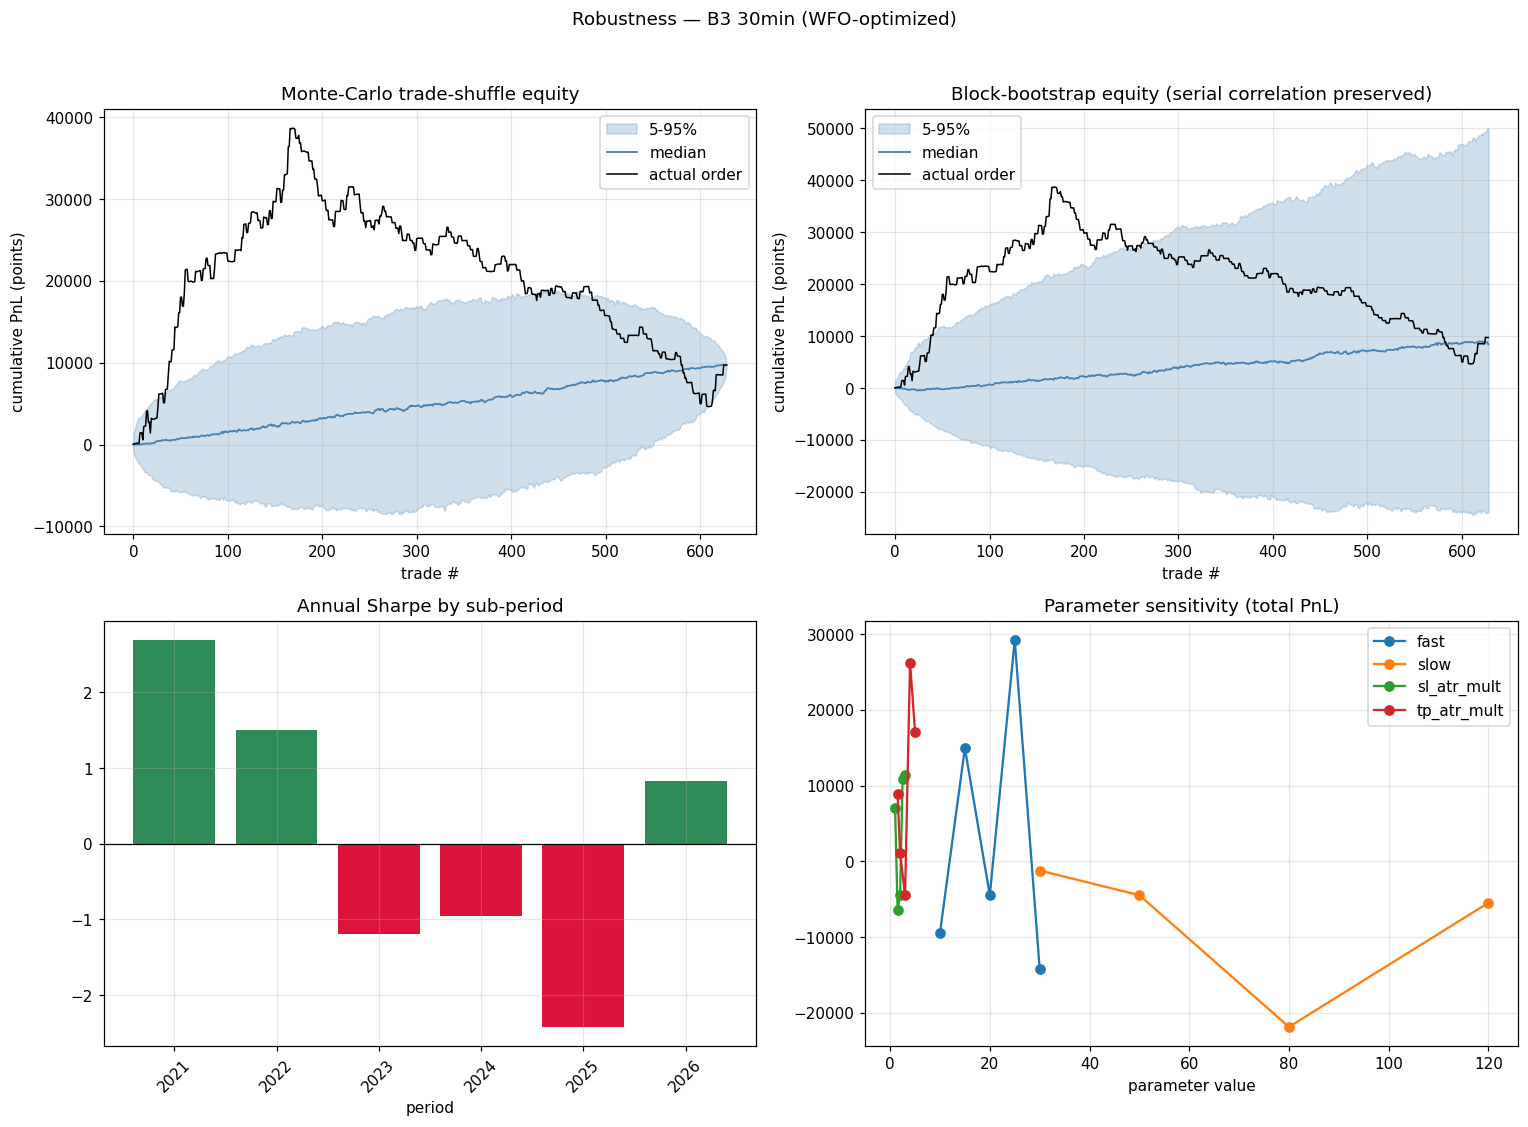

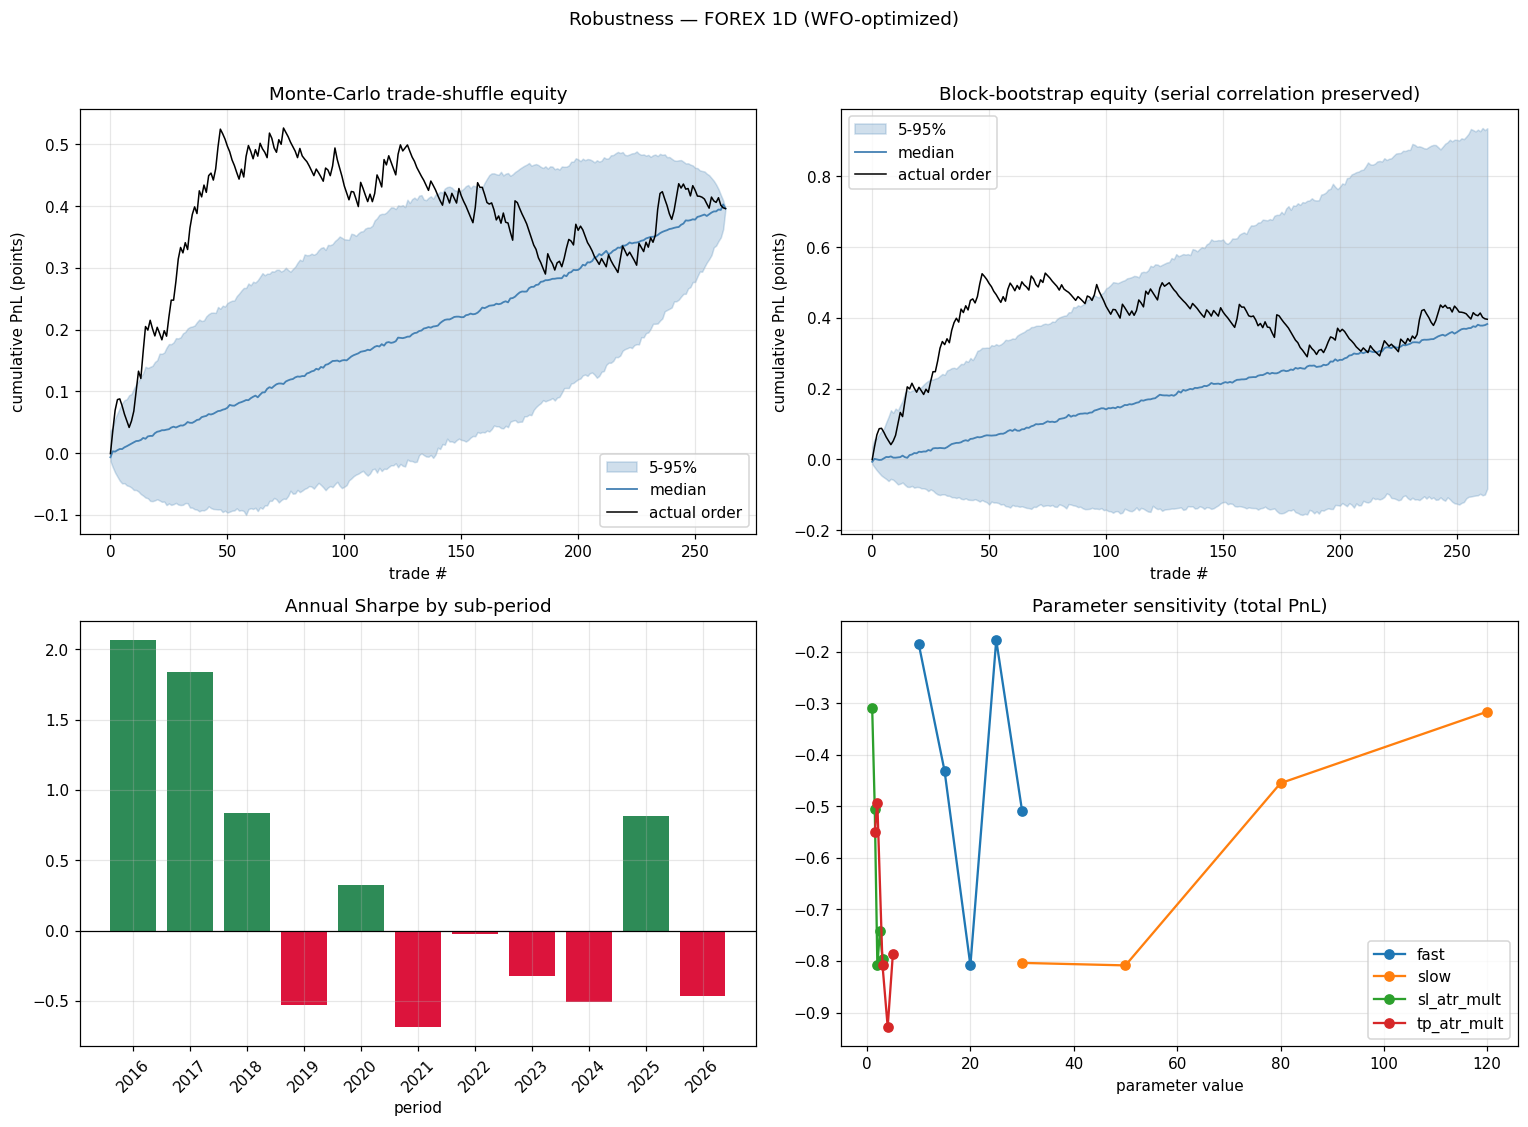

In [16]:
for group, tf in best_tfs.items():
    if tf is None or group not in mc_results or group not in sensitivity_results:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        continue
    actual_equity = opt_trades["pnl_points"].cumsum().values
    fig = plot_robustness_dashboard(
        mc_results[group],
        baseline_equity=actual_equity,
        sensitivity=sensitivity_results[group],
        block_bootstrap_df=block_boot_results.get(group),
        subperiod_df=subperiod_results.get(group),
    )
    fig.suptitle(f"Robustness — {group.upper()} {tf} (WFO-optimized)", y=1.02)
    plt.show()

### 5.4 Synthetic Asset Simulation

A complementary robustness probe that tests whether the strategy's statistical properties
remain stable on **artificially constructed assets** that have never been traded, but share
the same distributional fingerprint as the real underlying data.

**Generation process**
1. A seed window of `SYNTH_INIT_WINDOW` real candles is copied verbatim as the starting state.
2. Each subsequent bar is produced by sampling a block of `SYNTH_BUILD_BLOCK` consecutive
   first-differences (Δopen, Δhigh, Δlow, Δclose) at random from the full historical pool
   and applying them to the last bar; OHLC validity is enforced after each step.
3. Generation continues until `SYNTH_MAX_BARS` bars exist, providing enough data for
   the indicators to warm up before trading begins.
4. Each asset's simulation is capped at `SYNTH_MAX_TRADES` recorded trades.

**Interpretation** — if the strategy's metrics on synthetic assets cluster around the same
values as on real data, the edge may be explainable purely by the autocorrelation
structure of price differences.  A notable divergence (better metrics on real data)
provides evidence of a genuine market inefficiency rather than an artefact of the
data-generating process.

In [17]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
SYNTH_INIT_WINDOW      = 5        # seed candles drawn from real data
SYNTH_BUILD_BLOCK      = 1        # consecutive first-differences per generation step
SYNTH_MAX_TRADES       = 2500     # cap trades per synthetic asset
SYNTH_ASSETS_PER_GROUP = 5        # synthetic assets to generate per market group
SYNTH_MAX_BARS         = 250_000  # max bars generated per asset (upper safety bound)
SYNTH_SEED             = 42


def generate_synthetic_asset(base_df, n_bars, init_window=5, block_size=1, rng=None):
    """Bootstrap first-differences from base_df to build a synthetic OHLC series."""
    if rng is None:
        rng = np.random.default_rng()
    cols  = ["open", "high", "low", "close"]
    arr   = base_df[cols].values.astype(float)
    diffs = np.diff(arr, axis=0)
    n_diffs   = len(diffs)
    max_start = max(1, n_diffs - block_size)

    synthetic = list(arr[:init_window])
    while len(synthetic) < n_bars:
        start = int(rng.integers(0, max_start))
        for diff_row in diffs[start : start + block_size]:
            if len(synthetic) >= n_bars:
                break
            prev    = synthetic[-1].copy()
            new_bar = prev + diff_row
            # Floor at a tiny fraction of the previous close to avoid non-positive prices
            new_bar = np.maximum(new_bar, prev * 1e-4)
            o, h, lv, c = new_bar
            # Enforce OHLC: high >= max(open, close), low <= min(open, close)
            h  = max(h, o, c)
            lv = min(lv, o, c)
            synthetic.append(np.array([o, h, lv, c]))

    synth_arr = np.array(synthetic[:n_bars])
    freq = (base_df.index[1] - base_df.index[0]) if len(base_df.index) >= 2 else pd.Timedelta("1min")
    idx  = pd.date_range(start=base_df.index[0], periods=n_bars, freq=freq)
    return pd.DataFrame(synth_arr, columns=cols, index=idx)


Generating synthetic assets — B3 30min


  synth_1 (base=WIN): 2,500 trades from 250,000 synthetic bars


  synth_2 (base=WDO): 2,500 trades from 250,000 synthetic bars


  synth_3 (base=WIN): 2,500 trades from 250,000 synthetic bars


  synth_4 (base=WDO): 2,500 trades from 250,000 synthetic bars


...

,real_data,synth_avg
num_trades,629.0000,"2,500.0000"
total_pnl,"9,714.0560","48,036.3588"
win_rate,0.5755,0.3666
profit_factor,1.1070,1.0048
expectancy,15.4437,19.2145
max_drawdown,"-34,051.5559","-100,703.5645"
sharpe_daily,0.2409,0.0145
sharpe_per_trade,0.6541,0.0387
p_value,0.5130,0.5253



Per-synthetic-asset metrics — FOREX 1D:


,num_trades,total_pnl,win_rate,profit_factor,expectancy,max_drawdown,sharpe_daily,sharpe_per_trade,p_value
synth_1 (base=EURCAD),"2,500.0000",1.6983,0.3696,1.0442,0.0007,-2.8248,0.0354,0.7382,0.4604
synth_2 (base=GBPCHF),"2,500.0000",-10.2551,0.3232,0.7346,-0.0041,-10.5215,-0.2681,-5.4385,0.0000
synth_3 (base=EURUSD),"2,500.0000",-2.6980,0.3460,0.9104,-0.0011,-3.4854,-0.0801,-1.6552,0.0979
synth_4 (base=EURCAD),"2,500.0000",-1.0273,0.3752,0.9735,-0.0004,-2.7905,-0.0227,-0.4792,0.6318
synth_5 (base=GBPCHF),"2,500.0000",-4.4384,0.3396,0.8781,-0.0018,-4.7813,-0.1075,-2.2229,0.0262



Real data vs synthetic average — FOREX 1D:


,real_data,synth_avg
num_trades,264.0000,"2,500.0000"
total_pnl,0.3961,-3.3441
win_rate,0.3485,0.3507
profit_factor,1.2620,0.9082
expectancy,0.0015,-0.0013
max_drawdown,-0.2366,-4.8807
sharpe_daily,0.4037,-0.0886
sharpe_per_trade,1.5237,-1.8115
p_value,0.1276,0.2433


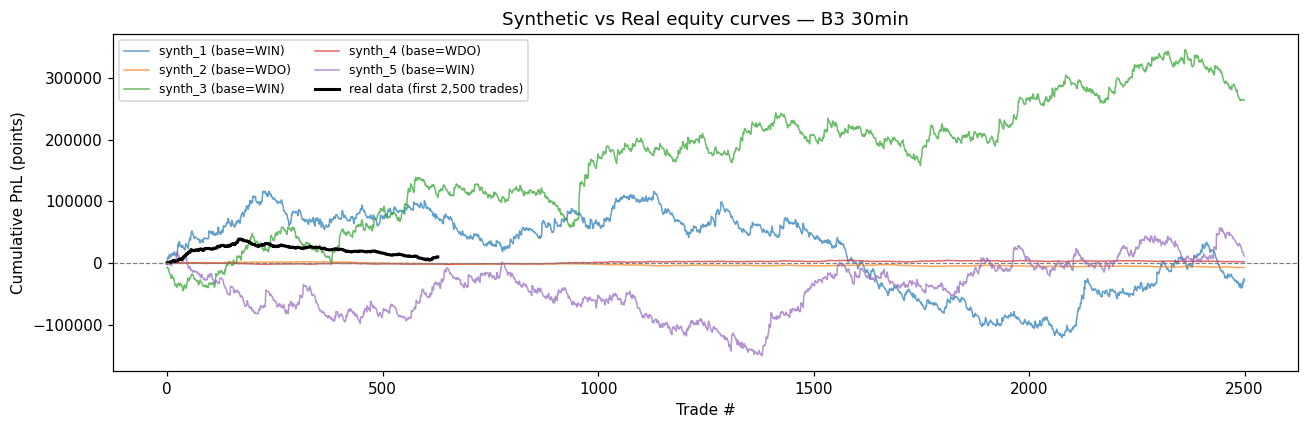

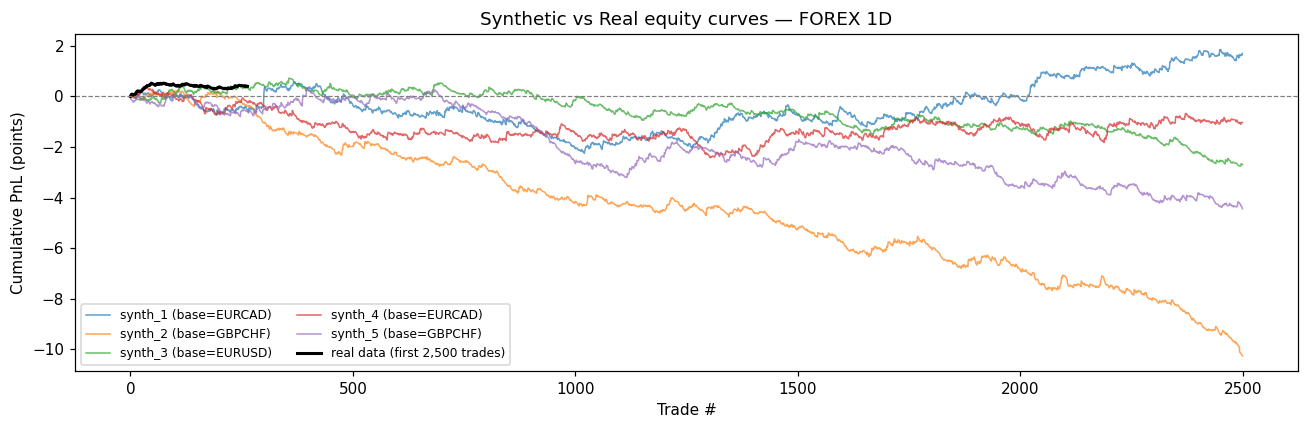

In [18]:
synth_results = {}   # [group] = {label: (result, truncated_trades, base_name)}

for group, tf in best_tfs.items():
    if tf is None:
        continue
    asset_lazies = group_tfs[group][tf]
    asset_names  = list(asset_lazies.keys())
    rng_group    = np.random.default_rng(SYNTH_SEED + abs(hash(group)) % 1000)

    print(f"\nGenerating synthetic assets — {group.upper()} {tf}")
    synth_results[group] = {}

    for i in range(SYNTH_ASSETS_PER_GROUP):
        base_name = asset_names[int(rng_group.integers(len(asset_names)))]
        # Materialize the base DataFrame just for this generation; unload it
        # immediately afterwards so the kernel doesn't accumulate copies.
        with asset_lazies[base_name].using() as base_df:
            synth_df = generate_synthetic_asset(
                base_df,
                n_bars      = SYNTH_MAX_BARS,
                init_window = SYNTH_INIT_WINDOW,
                block_size  = SYNTH_BUILD_BLOCK,
                rng         = np.random.default_rng(SYNTH_SEED + i),
            )

        result = Backtester(
            SMACrossoverStrategy(baseline_params), slippage_points=0.0
        ).run(synth_df)
        del synth_df
        gc.collect()

        trades = (
            result.trades.iloc[:SYNTH_MAX_TRADES].copy()
            if not result.trades.empty else pd.DataFrame()
        )
        label = f"synth_{i + 1}"
        synth_results[group][label] = (result, trades, base_name)
        print(f"  {label} (base={base_name}): {len(trades):,} trades "
              f"from {SYNTH_MAX_BARS:,} synthetic bars")

# ── Per-asset metrics table ──────────────────────────────────────────────────
for group, tf in best_tfs.items():
    if tf is None or group not in synth_results:
        continue

    rows = {}
    for label, (_, trades, base_name) in synth_results[group].items():
        if trades.empty:
            continue
        eq = pd.Series(
            trades["pnl_points"].cumsum().values,
            index=pd.to_datetime(trades["exit_time"].values),
        )
        m = compute_metrics(_PortfolioResult(trades, eq))
        rows[f"{label} (base={base_name})"] = {k: m[k] for k in SUMMARY_METRICS if k in m}

    if not rows:
        print(f"\n{group.upper()} {tf}: no synthetic trades generated")
        continue

    print(f"\nPer-synthetic-asset metrics — {group.upper()} {tf}:")
    display(pd.DataFrame(rows).T)

    real_m   = compute_metrics(optimized_portfolio[group][tf])
    real_row = {k: real_m[k] for k in SUMMARY_METRICS if k in real_m}

    synth_row_list = list(rows.values())
    avg_row = {
        k: np.mean([r[k] for r in synth_row_list if k in r and pd.notna(r[k])])
        for k in SUMMARY_METRICS
    }

    print(f"\nReal data vs synthetic average — {group.upper()} {tf}:")
    display(pd.DataFrame({"real_data": real_row, "synth_avg": avg_row}))

# ── Equity curves: synthetic vs real ────────────────────────────────────────
for group, tf in best_tfs.items():
    if tf is None or group not in synth_results:
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    for label, (_, trades, base_name) in synth_results[group].items():
        if trades.empty:
            continue
        eq = trades["pnl_points"].cumsum().reset_index(drop=True)
        ax.plot(eq.values, alpha=0.7, linewidth=1.0,
                label=f"{label} (base={base_name})")

    real_trades = optimized_portfolio[group][tf].trades
    if not real_trades.empty:
        real_eq = (
            real_trades["pnl_points"]
            .cumsum()
            .iloc[:SYNTH_MAX_TRADES]
            .reset_index(drop=True)
        )
        ax.plot(real_eq.values, color="black", linewidth=2.0,
                label=f"real data (first {SYNTH_MAX_TRADES:,} trades)")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(f"Synthetic vs Real equity curves — {group.upper()} {tf}")
    ax.set_xlabel("Trade #")
    ax.set_ylabel("Cumulative PnL (points)")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


## 6. Takeaways & next steps

**What this notebook gives us**
- A reproducible pipeline: load → multi-timeframe resample → baseline backtest → WFO →
  robustness, run **independently** for the Forex and B3 groups.
- Cross-timeframe comparison tables for each group so we can identify which horizon
  the strategy fits best.
- A concrete baseline to beat with more sophisticated strategies.

**Known simplifications** (intentional — next iterations, not bugs)
- Bar-close execution, no realistic fill modelling, unit sizing, no commissions.
- Intra-bar SL-before-TP assumption may under-state TP hits.
- WFO folds are fixed equal slices — anchored or expanding-window WFO is a natural
  follow-up.
- B3 futures are BRL-denominated — cross-group raw-point PnL comparison is not
  meaningful; normalise by a notional value or trade in percent-of-price before
  comparing the two groups.

**Extensions (implemented in Section 7)**
- Session / time-of-day filters (B3: 09:00-18:00; Forex: optional).
- Volatility-scaled and fixed-fractional position sizing.
- Correlation-aware cross-asset portfolio weighting (equal / inv-vol / min-var).
- Classifier signal overlay → `machine_learning/01_classifier_signal_filter.ipynb`.

## 7. Extensions

### 7.1 Session / time-of-day filter (B3)

B3 mini-futures (WDO, WIN) trade from ~09:00 to ~18:00 local time.
The raw data extends to 18:29; bars after 18:00 are low-liquidity.
`session_start=9, session_end=18` does two things:
1. Suppresses new entry signals outside the window.
2. Forces positions to close at the last bar still inside the window (avoids holding through the liquidity gap).

In [19]:
session_params = StrategyParams(
    fast=20, slow=50, atr_period=14, sl_atr_mult=2.0, tp_atr_mult=3.0,
    session_start=9, session_end=18,
)

# B3-only sub-grid; runner loads + unloads inside each worker so RAM stays flat.
b3_grid = {"b3": group_tfs["b3"]}
session_flat = run_backtest_grid(
    b3_grid,
    session_params,
    strategy_cls=SMACrossoverStrategy,
    n_jobs=N_JOBS,
    progress=False,
)
session_per_asset = reshape_grid_results(session_flat).get("b3", {})
session_portfolio = {tf: build_portfolio(by_asset) for tf, by_asset in session_per_asset.items()}

compare_rows = {}
for tf in GROUP_TIMEFRAMES["b3"]:
    m_base = compute_metrics(baseline_portfolio["b3"][tf])
    m_sess = compute_metrics(session_portfolio[tf])
    t_sess = session_portfolio[tf].trades
    n_ses_exits = int((t_sess["reason"] == "SESSION_END").sum()) if not t_sess.empty else 0
    compare_rows[tf] = {
        "base_trades":   m_base["num_trades"],
        "sess_trades":   m_sess["num_trades"],
        "session_exits": n_ses_exits,
        "base_sharpe":   m_base["sharpe_daily"],
        "sess_sharpe":   m_sess["sharpe_daily"],
        "base_pnl":      m_base["total_pnl"],
        "sess_pnl":      m_sess["total_pnl"],
        "base_maxdd":    m_base["max_drawdown"],
        "sess_maxdd":    m_sess["max_drawdown"],
    }

print("Baseline vs Session-filtered — B3 (all assets combined per TF):")
display(pd.DataFrame(compare_rows).T)


Baseline vs Session-filtered — B3 (all assets combined per TF):


,base_trades,sess_trades,session_exits,base_sharpe,sess_sharpe,base_pnl,sess_pnl,base_maxdd,sess_maxdd
1min,"31,989.0000","30,989.0000",601.0000,-0.3635,-0.4888,"-31,314.5979","-42,161.7576","-56,858.8929","-62,818.0266"
5min,"6,247.0000","6,046.0000",690.0000,0.1579,0.1762,"14,746.2696","15,890.5647","-19,256.0384","-27,621.9596"
15min,"2,100.0000","2,038.0000",648.0000,-0.0374,0.2943,"-3,645.4576","24,791.8812","-40,835.9753","-35,613.2900"
30min,992.0000,949.0000,451.0000,-0.0509,0.0320,"-4,467.3764","2,251.6226","-27,661.8280","-27,321.4474"


### 7.2 Position sizing

Three modes are compared on each group's best-OOS timeframe:

| Mode | Size formula | PnL unit |
|------|-------------|----------|
| `unit` | 1 contract | price points |
| `vol_scaled` | 1 / ATR | ATR-normalised (dimensionless, comparable across assets) |
| `fixed_frac` | equity × risk_fraction / (sl_mult × ATR) | price points × contracts |

`vol_scaled` equalises risk per trade across timeframes; `fixed_frac` sizes positions
by a fixed percentage of current equity (Kelly-light).

In [20]:
SIZING_MODES = ["unit", "vol_scaled", "fixed_frac"]
INITIAL_CAPITAL = 100_000.0

sizing_compare = {}
for group, tf in best_tfs.items():
    if tf is None:
        continue
    sub_grid = {group: {tf: group_tfs[group][tf]}}
    sizing_compare[f"{group}/{tf}"] = {}
    for mode in SIZING_MODES:
        p = StrategyParams(
            fast=20, slow=50, atr_period=14, sl_atr_mult=2.0, tp_atr_mult=3.0,
            sizing_mode=mode, risk_fraction=0.01,
        )
        flat = run_backtest_grid(
            sub_grid,
            p,
            strategy_cls=SMACrossoverStrategy,
            initial_capital=INITIAL_CAPITAL,
            n_jobs=N_JOBS,
            progress=False,
        )
        per_asset = reshape_grid_results(flat).get(group, {}).get(tf, {})
        portfolio = build_portfolio(per_asset)
        m = compute_metrics(portfolio)
        sizing_compare[f"{group}/{tf}"][mode] = {
            k: m[k] for k in ["num_trades", "sharpe_daily", "profit_factor",
                               "win_rate", "max_drawdown", "total_pnl"]
        }

for label, modes in sizing_compare.items():
    print(f"\nSizing comparison — {label}  (fixed_frac initial_capital={INITIAL_CAPITAL:,.0f})")
    display(pd.DataFrame(modes))



Sizing comparison — b3/30min  (fixed_frac initial_capital=100,000)


,unit,vol_scaled,fixed_frac
num_trades,992.0000,992.0000,992.0000
sharpe_daily,-0.0509,0.1706,0.1200
profit_factor,0.9867,1.0351,1.0256
win_rate,0.4002,0.4002,0.4002
max_drawdown,"-27,661.8280",-73.7282,"-45,678.6857"
total_pnl,"-4,467.3764",38.1176,"15,554.2565"



Sizing comparison — forex/1D  (fixed_frac initial_capital=100,000)


,unit,vol_scaled,fixed_frac
num_trades,192.0000,192.0000,192.0000
sharpe_daily,-0.7363,-0.7032,-0.7214
profit_factor,0.6320,0.6562,0.6484
win_rate,0.3021,0.3021,0.3021
max_drawdown,-0.7955,-85.4447,"-39,596.4973"
total_pnl,-0.8086,-84.9841,"-40,003.6752"


### 7.3 Correlation-aware cross-asset portfolio weighting

Within each group, the assets may be correlated (e.g. EURUSD and EURCAD share the EUR leg).
Allocating equal nominal weight to each asset over-concentrates risk on the dominant
risk factor. Three weighting schemes are compared:

| Method | Idea |
|--------|------|
| `equal` | 1/n per asset — ignores correlation |
| `inv_vol` | weight ∝ 1/σ — lower-volatility assets get larger weight |
| `min_var` | minimum-variance portfolio via Σ⁻¹·1 (long-only) |

PnL is in `pnl_weighted = pnl_points × weight` units, making Sharpe comparable across methods.

In [21]:
CORR_METHODS = ["equal", "inv_vol", "min_var"]

corr_summary = {}
for group, tf in best_tfs.items():
    if tf is None:
        continue
    per_asset = baseline_per_asset[group][tf]
    eq_curves = {asset: res.equity for asset, res in per_asset.items()}

    group_rows = {}
    for method in CORR_METHODS:
        weights = correlation_weights(eq_curves, lookback_days=60, method=method)
        trades_w, equity_w = weighted_portfolio(per_asset, weights)
        trades_w = trades_w.copy()
        trades_w["pnl_points"] = trades_w["pnl_weighted"]
        m = compute_metrics(_PortfolioResult(trades_w, equity_w))
        group_rows[method] = {
            **{f"w_{a}": f"{weights.get(a, 0):.3f}" for a in eq_curves},
            "sharpe_daily":   m["sharpe_daily"],
            "profit_factor":  m["profit_factor"],
            "max_drawdown":   m["max_drawdown"],
            "total_pnl":      m["total_pnl"],
        }

    label = f"{group}/{tf}"
    corr_summary[label] = pd.DataFrame(group_rows).T
    print(f"\nCorrelation-aware weighting — {label}:")
    display(corr_summary[label])



Correlation-aware weighting — b3/30min:


,w_WDO,w_WIN,sharpe_daily,profit_factor,max_drawdown,total_pnl
equal,0.500,0.500,-0.0509,0.9867,"-13,830.9140","-2,233.6882"
inv_vol,0.981,0.019,0.3798,1.0862,"-1,030.5867","1,312.1920"
min_var,1.000,0.000,0.5112,1.1560,-919.0154,"1,449.9808"



Correlation-aware weighting — forex/1D:


,w_EURCAD,w_EURUSD,w_GBPCHF,sharpe_daily,profit_factor,max_drawdown,total_pnl
equal,0.333,0.333,0.333,-0.7363,0.6320,-0.2652,-0.2695
inv_vol,0.292,0.416,0.292,-0.6835,0.6537,-0.2362,-0.2441
min_var,0.250,0.504,0.246,-0.6060,0.6787,-0.2100,-0.2170
